In [23]:
import sys
sys.path.insert(0, '..')

import json, re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown

from src.metrics.persuasiveness import Persuasiveness, PersuasivenessPostFlip

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'databricks_full_run1'

W_VALUES = [1, 2, 5]
W_COLORS = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
SCORE_COLORS = {'pers': '#4C72B0', 'pers_plus': '#C44E52'}
CEILING = 10.0

pers_metric      = Persuasiveness()
pers_plus_metric = PersuasivenessPostFlip(ceiling=CEILING)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [24]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_key = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        ds  = d.get('dataset', 'unknown')
        key = (ds, qid)
        if key not in by_key or str(f) > by_key[key]['_path']:
            d['_path'] = str(f)
            by_key[key] = d
    return by_key

raw = {w: load_window_data(w) for w in W_VALUES}
common_keys = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'Common (dataset, qid) pairs across W=1,2,5: {len(common_keys)} — {common_keys}')

Common (dataset, qid) pairs across W=1,2,5: 30 — [('gpqa', '12'), ('gpqa', '129'), ('gpqa', '136'), ('gpqa', '157'), ('gpqa', '159'), ('gpqa', '168'), ('gpqa', '17'), ('gpqa', '182'), ('gpqa', '24'), ('gpqa', '42'), ('gpqa', '47'), ('gpqa', '61'), ('gpqa', '7'), ('gpqa', '8'), ('gpqa', '95'), ('hiddenbench', '13'), ('hiddenbench', '14'), ('hiddenbench', '15'), ('hiddenbench', '18'), ('hiddenbench', '2'), ('hiddenbench', '24'), ('hiddenbench', '28'), ('hiddenbench', '31'), ('hiddenbench', '35'), ('hiddenbench', '41'), ('hiddenbench', '43'), ('hiddenbench', '46'), ('hiddenbench', '57'), ('hiddenbench', '6'), ('hiddenbench', '8')]


## Compute Persuasiveness Scores

In [25]:
records = []
for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys:
            continue
        gt = d['ground_truth']
        dataset = ds_key
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            p_scores  = pers_metric.score(rep)
            pp_scores = pers_plus_metric.score(rep)
            votes_final = [traj[-1]['phase_b'][a]['vote'] for a in range(N)]
            majority_final = max(set(votes_final), key=votes_final.count)
            rep_correct = majority_final == gt
            rep_converged = len(set(votes_final)) == 1
            for a in range(N):
                v0 = traj[0]['phase_b'][a]['vote']
                vf = traj[-1]['phase_b'][a]['vote']
                confs = [traj[t]['phase_b'][a].get('confidence') or 0 for t in range(T)]
                msgs  = [traj[t]['phase_b'][a].get('message','') for t in range(T)]
                reas  = [traj[t]['phase_b'][a].get('reasoning','') for t in range(T)]
                pt = sum(traj[t]['phase_b'][a].get('prompt_tokens', 0) for t in range(T))
                ct = sum(traj[t]['phase_b'][a].get('completion_tokens', 0) for t in range(T))
                own_flips = sum(
                    1 for t in range(1, T)
                    if traj[t]['phase_b'][a]['vote'] != traj[t-1]['phase_b'][a]['vote']
                )
                votes_r0 = [traj[0]['phase_b'][b]['vote'] for b in range(N)]
                in_majority_r0 = votes_r0.count(v0) > N / 2
                combined_text = ' '.join(msgs)
                math_count   = len(re.findall(r'\d+\.?\d*', combined_text))
                formula_count = len(re.findall(r'[=<>≈±×÷∑∫√]', combined_text))
                hedge_count  = len(re.findall(
                    r'\b(however|although|but|yet|while|though|uncertain|maybe|perhaps|possibly)\b',
                    combined_text, re.I
                ))
                assert_count = len(re.findall(
                    r'\b(therefore|thus|clearly|obviously|must|certainly|definitely|conclude)\b',
                    combined_text, re.I
                ))
                avg_msg_len  = np.mean([len(m.split()) for m in msgs]) if msgs else 0
                avg_reas_len = np.mean([len(r.split()) for r in reas]) if reas else 0
                records.append({
                    'W': w, 'qid': qid, 'dataset': dataset,
                    'rep': rep_idx, 'agent': a,
                    'pers':       p_scores[a],
                    'pers_plus':  pp_scores[a],
                    'T': T, 'N': N,
                    'own_flips':     own_flips,
                    'in_majority_r0': in_majority_r0,
                    'conf_r0':     confs[0],
                    'conf_final':  confs[-1],
                    'conf_mean':   np.mean(confs),
                    'conf_delta':  confs[-1] - confs[0],
                    'prompt_tokens':     pt,
                    'completion_tokens': ct,
                    'total_tokens':      pt + ct,
                    'initial_correct': v0 == gt,
                    'final_correct':   vf == gt,
                    'rep_correct':     rep_correct,
                    'rep_converged':   rep_converged,
                    'math_count':    math_count,
                    'formula_count': formula_count,
                    'hedge_count':   hedge_count,
                    'assert_count':  assert_count,
                    'avg_msg_len':   avg_msg_len,
                    'avg_reas_len':  avg_reas_len,
                })

df = pd.DataFrame(records)
print(f'Rows: {len(df)}  ({df["dataset"].value_counts().to_dict()})')
print(f'Pers  range: [{df["pers"].min():.3f}, {df["pers"].max():.3f}]  mean={df["pers"].mean():.3f}')
print(f'Pers+ range: [{df["pers_plus"].min():.3f}, {df["pers_plus"].max():.3f}]  mean={df["pers_plus"].mean():.3f}')
display(df.head(8))

Rows: 18000  ({'gpqa': 9000, 'hiddenbench': 9000})
Pers  range: [-1.000, 1.000]  mean=0.160
Pers+ range: [-0.836, 1.000]  mean=0.137


,W,qid,dataset,rep,agent,pers,pers_plus,T,N,own_flips,...,initial_correct,final_correct,rep_correct,rep_converged,math_count,formula_count,hedge_count,assert_count,avg_msg_len,avg_reas_len
0,1,95,gpqa,0,0,-0.548387,-0.435065,6,4,2,...,False,False,False,True,35,0,1,0,77.166667,177.000000
1,1,95,gpqa,0,1,0.652632,0.555556,6,4,1,...,True,False,False,True,30,0,0,1,63.500000,247.500000
2,1,95,gpqa,0,2,0.586207,0.481013,6,4,0,...,False,False,False,True,38,0,0,2,67.500000,195.333333
3,1,95,gpqa,0,3,-0.416667,-0.332180,6,4,2,...,False,False,False,True,49,0,0,4,75.166667,183.833333
4,1,95,gpqa,1,0,-0.290323,-0.257143,4,4,1,...,True,False,False,True,13,0,0,4,43.250000,290.500000
5,1,95,gpqa,1,1,1.000000,0.945946,4,4,0,...,False,False,False,True,17,0,0,1,42.750000,229.750000
6,1,95,gpqa,1,2,1.000000,0.945946,4,4,0,...,False,False,False,True,26,0,0,0,51.500000,165.500000
7,1,95,gpqa,1,3,-0.258065,-0.242857,4,4,1,...,False,False,False,True,20,0,0,3,46.250000,278.750000


---
# Part 1 — Score Distributions

We look at how the persuasiveness scores are distributed across agents, separately for each
dataset and each memory window size. Both `Pers` (base) and `Pers+` (post-flip variant) are shown.
A histogram with a fitted KDE lets us see whether the distribution is symmetric around zero,
skewed, or has notable mass at the extremes.

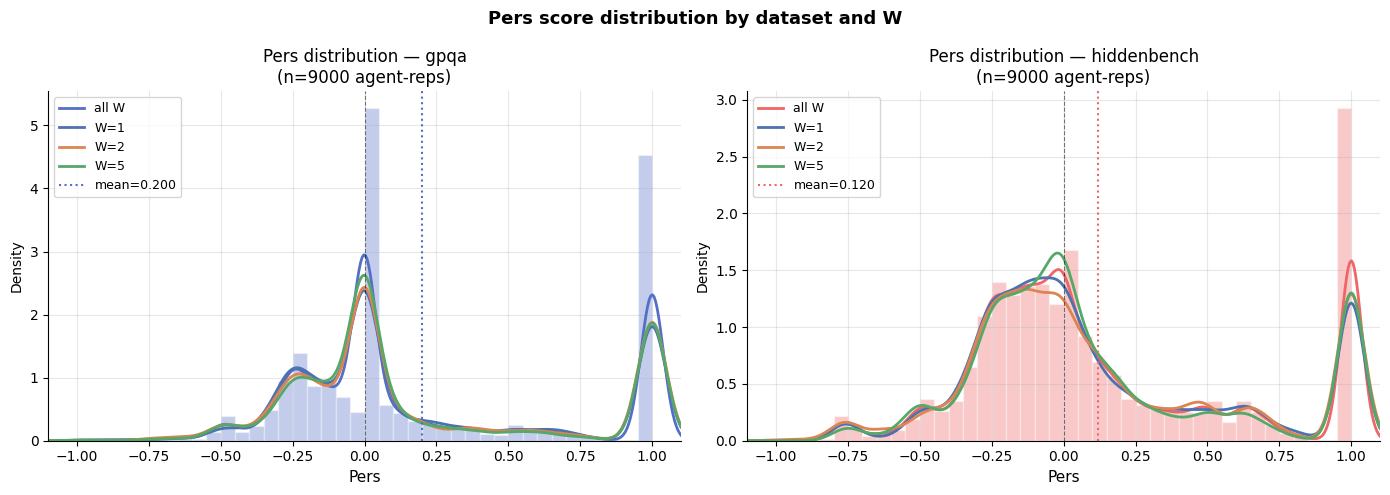

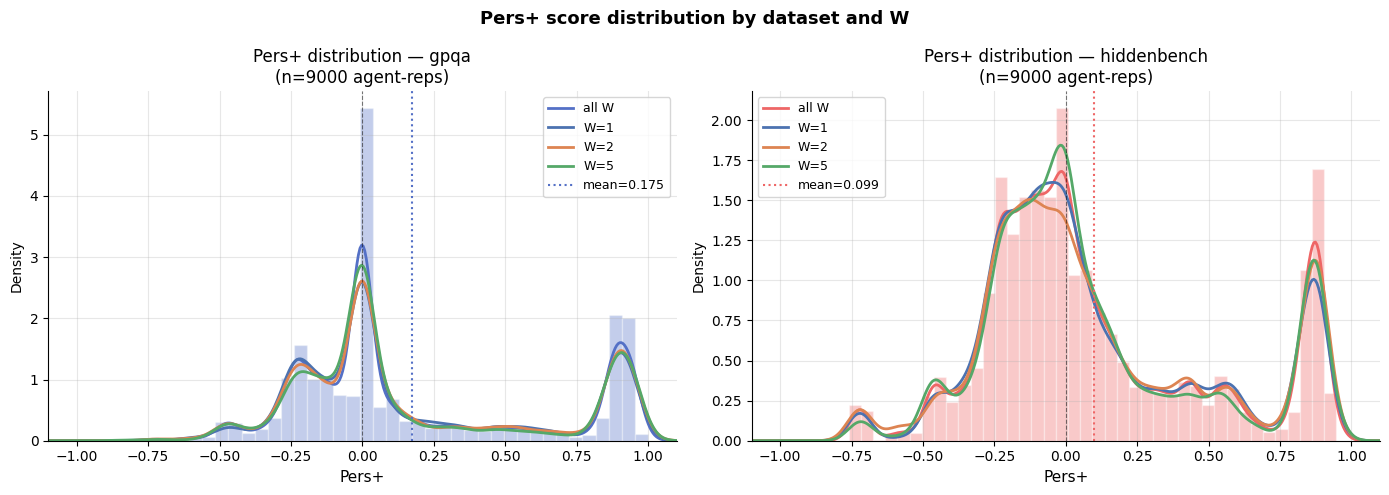

Descriptive stats:


pers               pers_plus              
                mean median    std      mean median    std
dataset     W                                             
gpqa        1  0.198  0.000  0.486     0.173  0.000  0.433
            2  0.204  0.000  0.495     0.179  0.000  0.441
            5  0.197  0.000  0.486     0.174  0.000  0.436
hiddenbench 1  0.118 -0.012  0.457     0.095 -0.009  0.397
            2  0.125  0.000  0.473     0.104 -0.003  0.411
            5  0.116 -0.006  0.454     0.097 -0.004  0.395

In [26]:
datasets = ['gpqa', 'hiddenbench']

def kde_line(ax, vals, color, label=None, bw=0.08):
    vals = vals[np.isfinite(vals)]
    if len(vals) < 5:
        return
    kde = gaussian_kde(vals, bw_method=bw)
    xs = np.linspace(-1.1, 1.1, 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2, label=label)

for score_col, score_label in [('pers', 'Pers'), ('pers_plus', 'Pers+')]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ds in zip(axes, datasets):
        sub = df[df['dataset'] == ds]
        ax.hist(sub[score_col], bins=40, density=True,
                color=DS_COLORS[ds], alpha=0.35, edgecolor='white')
        kde_line(ax, sub[score_col].values, DS_COLORS[ds], label='all W')
        for w in W_VALUES:
            subw = sub[sub['W'] == w]
            kde_line(ax, subw[score_col].values, W_COLORS[w],
                     label=f'W={w}', bw=0.1)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.axvline(sub[score_col].mean(), color=DS_COLORS[ds],
                   linewidth=1.5, linestyle=':', label=f'mean={sub[score_col].mean():.3f}')
        ax.set_xlabel(score_label, fontsize=11)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{score_label} distribution — {ds}\n(n={len(sub)} agent-reps)', fontsize=12)
        ax.legend(fontsize=9)
        ax.set_xlim(-1.1, 1.1)
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig.suptitle(f'{score_label} score distribution by dataset and W', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Descriptive stats:')
display(
    df.groupby(['dataset', 'W'])[['pers', 'pers_plus']]
    .agg(['mean', 'median', 'std'])
    .round(3)
)

### Per-question distribution

The above pools all agent-reps. Below we aggregate to question level (mean over agents and reps)
so we can see whether certain questions systematically produce high or low persuasiveness.

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Se

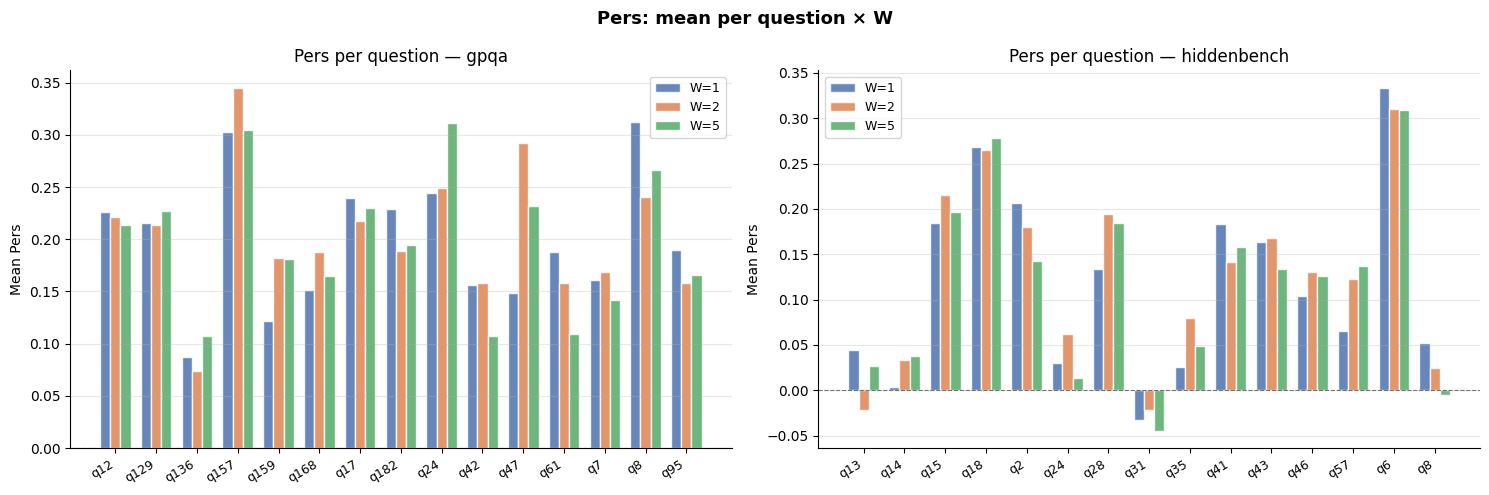

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/98684064.py:11: UserWarning: Boolean Se

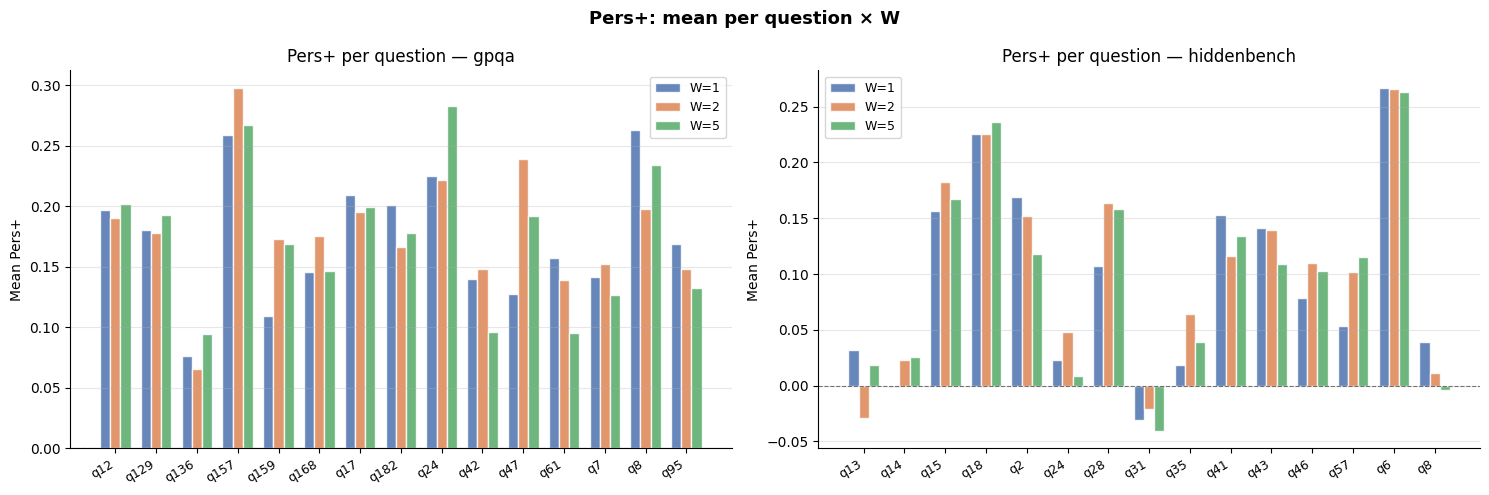

In [27]:
qdf = df.groupby(['dataset', 'qid', 'W'])[['pers', 'pers_plus']].mean().reset_index()

for score_col, score_label in [('pers', 'Pers'), ('pers_plus', 'Pers+')]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, ds in zip(axes, datasets):
        sub = qdf[qdf['dataset'] == ds].copy()
        qids = sorted(sub['qid'].unique())
        x = np.arange(len(qids))
        w_bar = 0.25
        for i, w in enumerate(W_VALUES):
            vals = [sub[sub['qid'] == q][sub['W'] == w][score_col].values[0]
                    if len(sub[(sub['qid'] == q) & (sub['W'] == w)]) > 0 else np.nan
                    for q in qids]
            ax.bar(x + (i-1)*w_bar, vals, w_bar,
                   color=W_COLORS[w], alpha=0.85, edgecolor='white', label=f'W={w}')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([f'q{q}' for q in qids], rotation=30, ha='right', fontsize=9)
        ax.set_ylabel(f'Mean {score_label}', fontsize=10)
        ax.set_title(f'{score_label} per question — {ds}', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig.suptitle(f'{score_label}: mean per question × W', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
# Part 2 — What Does High Persuasiveness Mean for System Outcome?

Here we ask: if a debate contains highly persuasive agents, does that predict better outcomes?
We look at this from two angles:

1. **Correctness** — does a high-persuasiveness debate land on the right answer more often?
2. **Convergence** — do debates with more persuasive agents converge (reach unanimous vote) more reliably?

We aggregate to repetition level: the persuasiveness of a debate = mean over agents.
We then split debates into high/low persuasiveness (above/below median per dataset) and compare outcomes.

In [28]:
rep_df = df.groupby(['dataset', 'W', 'qid', 'rep']).agg(
    pers_mean=('pers', 'mean'),
    pers_max=('pers', 'max'),
    pers_plus_mean=('pers_plus', 'mean'),
    pers_spread=('pers', lambda x: x.max() - x.min()),
    rep_correct=('rep_correct', 'first'),
    rep_converged=('rep_converged', 'first'),
    T=('T', 'first'),
).reset_index()

print(f'Rep-level rows: {len(rep_df)}')
display(rep_df.head(8))

Rep-level rows: 4500


,dataset,W,qid,rep,pers_mean,pers_max,pers_plus_mean,pers_spread,rep_correct,rep_converged,T
0,gpqa,1,12,0,0.678571,1.000000,0.606061,1.285714,True,True,4
1,gpqa,1,12,1,0.003835,0.083333,0.003329,0.216312,False,True,9
2,gpqa,1,12,2,0.683333,1.000000,0.646739,1.266667,True,True,4
3,gpqa,1,12,3,0.127722,1.000000,0.061002,1.297297,False,True,5
4,gpqa,1,12,4,0.098484,0.512000,0.086169,0.642952,False,True,7
5,gpqa,1,12,5,0.029633,0.460674,0.026540,0.582169,False,True,6
6,gpqa,1,12,6,0.081205,0.716216,0.070655,0.958152,False,True,5
7,gpqa,1,12,7,0.024100,0.369565,0.020175,0.739936,False,True,7


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/479545315.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)[y_col]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/479545315.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)[y_col]
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/479545315.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence

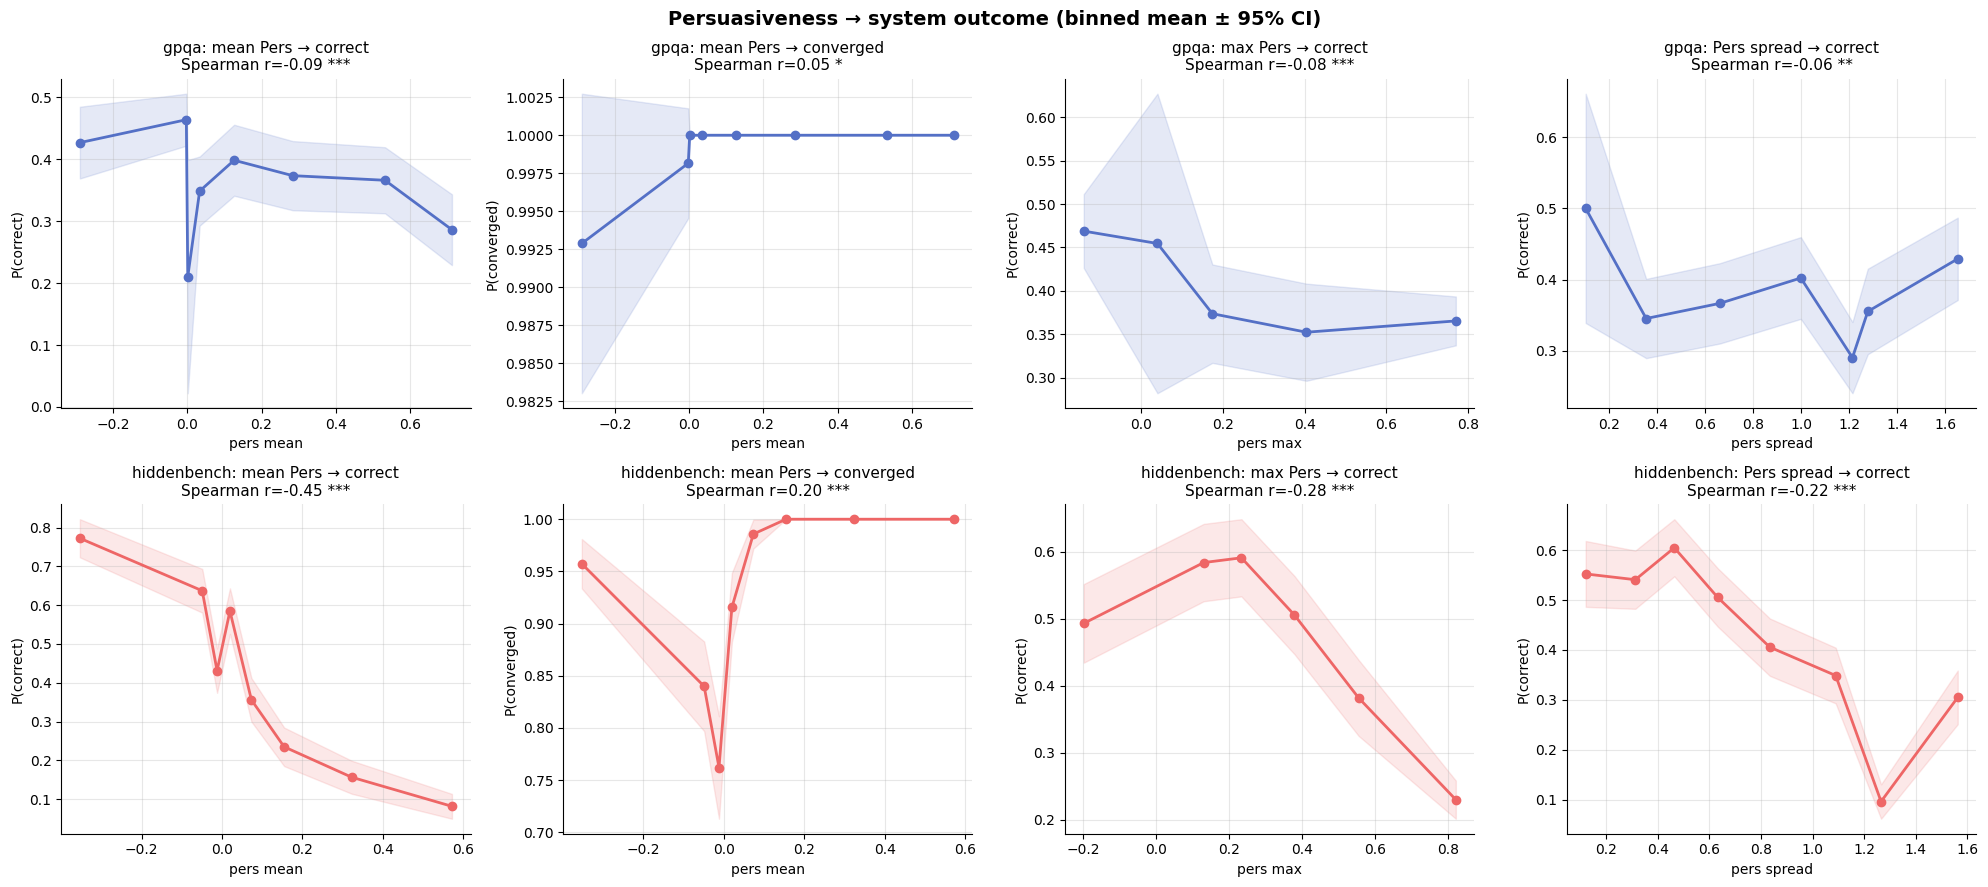

In [29]:
def binned_outcome(ax, sub, x_col, y_col, color, n_bins=8, ylabel='', title=''):
    bins = np.percentile(sub[x_col], np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    labels = (bins[:-1] + bins[1:]) / 2
    cut = pd.cut(sub[x_col], bins=bins, labels=labels)
    grp = sub.groupby(cut)[y_col]
    means, sems, ns = grp.mean(), grp.sem(), grp.count()
    valid = ns >= 3
    xs = means.index.astype(float)[valid]
    ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
    ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                    color=color, alpha=0.15)
    r, p = sp_stats.spearmanr(sub[x_col], sub[y_col])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(x_col.replace('_', ' '), fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{title}\nSpearman r={r:.2f} {sig}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for row, ds in enumerate(datasets):
    sub = rep_df[rep_df['dataset'] == ds]
    color = DS_COLORS[ds]
    binned_outcome(axes[row,0], sub, 'pers_mean', 'rep_correct',
                   color, ylabel='P(correct)', title=f'{ds}: mean Pers → correct')
    binned_outcome(axes[row,1], sub, 'pers_mean', 'rep_converged',
                   color, ylabel='P(converged)', title=f'{ds}: mean Pers → converged')
    binned_outcome(axes[row,2], sub, 'pers_max', 'rep_correct',
                   color, ylabel='P(correct)', title=f'{ds}: max Pers → correct')
    binned_outcome(axes[row,3], sub, 'pers_spread', 'rep_correct',
                   color, ylabel='P(correct)', title=f'{ds}: Pers spread → correct')

fig.suptitle('Persuasiveness → system outcome (binned mean ± 95% CI)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

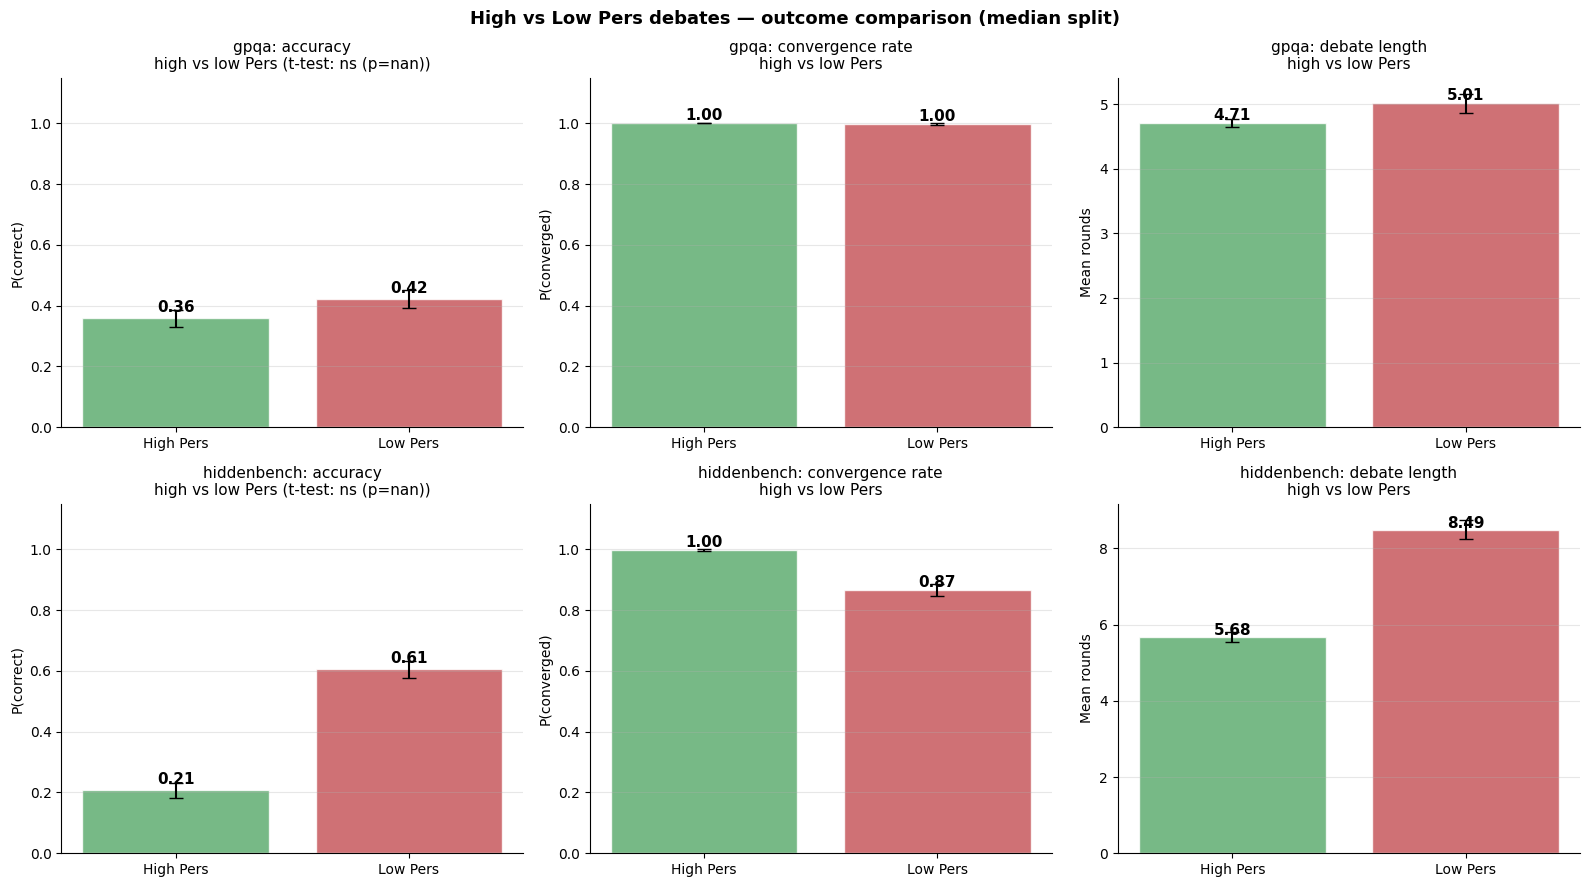

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, ds in enumerate(datasets):
    sub = rep_df[rep_df['dataset'] == ds].copy()
    med = sub['pers_mean'].median()
    sub['pers_group'] = (sub['pers_mean'] > med).map({True: 'High Pers', False: 'Low Pers'})

    ax = axes[row, 0]
    for grp, color in [('High Pers', '#55A868'), ('Low Pers', '#C44E52')]:
        vals = sub[sub['pers_group'] == grp]
        ax.bar(grp, vals['rep_correct'].mean(), color=color, alpha=0.8, edgecolor='white')
        ax.errorbar(grp, vals['rep_correct'].mean(),
                    yerr=vals['rep_correct'].sem()*1.96,
                    fmt='none', color='black', capsize=5)
        ax.text(grp, vals['rep_correct'].mean() + 0.02,
                f'{vals["rep_correct"].mean():.2f}', ha='center', fontsize=11, fontweight='bold')
    t, p = sp_stats.ttest_ind(
        sub[sub['pers_group']=='High Pers']['rep_correct'],
        sub[sub['pers_group']=='Low Pers']['rep_correct']
    )
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'ns (p={p:.2f})'
    ax.set_title(f'{ds}: accuracy\nhigh vs low Pers (t-test: {sig})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('P(correct)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    for grp, color in [('High Pers', '#55A868'), ('Low Pers', '#C44E52')]:
        vals = sub[sub['pers_group'] == grp]
        ax.bar(grp, vals['rep_converged'].mean(), color=color, alpha=0.8, edgecolor='white')
        ax.errorbar(grp, vals['rep_converged'].mean(),
                    yerr=vals['rep_converged'].sem()*1.96,
                    fmt='none', color='black', capsize=5)
        ax.text(grp, vals['rep_converged'].mean() + 0.01,
                f'{vals["rep_converged"].mean():.2f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{ds}: convergence rate\nhigh vs low Pers', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('P(converged)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for grp, color in [('High Pers', '#55A868'), ('Low Pers', '#C44E52')]:
        vals = sub[sub['pers_group'] == grp]['T']
        ax.bar(grp, vals.mean(), color=color, alpha=0.8, edgecolor='white')
        ax.errorbar(grp, vals.mean(), yerr=vals.sem()*1.96,
                    fmt='none', color='black', capsize=5)
        ax.text(grp, vals.mean() + 0.05, f'{vals.mean():.2f}',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{ds}: debate length\nhigh vs low Pers', fontsize=11)
    ax.set_ylabel('Mean rounds', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('High vs Low Pers debates — outcome comparison (median split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Pers vs Pers+ comparison on outcome prediction

Do the two score variants carry different predictive signal for correctness?

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/1100851571.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['rep_correct']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/1100851571.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['rep_correct']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/1100851571.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

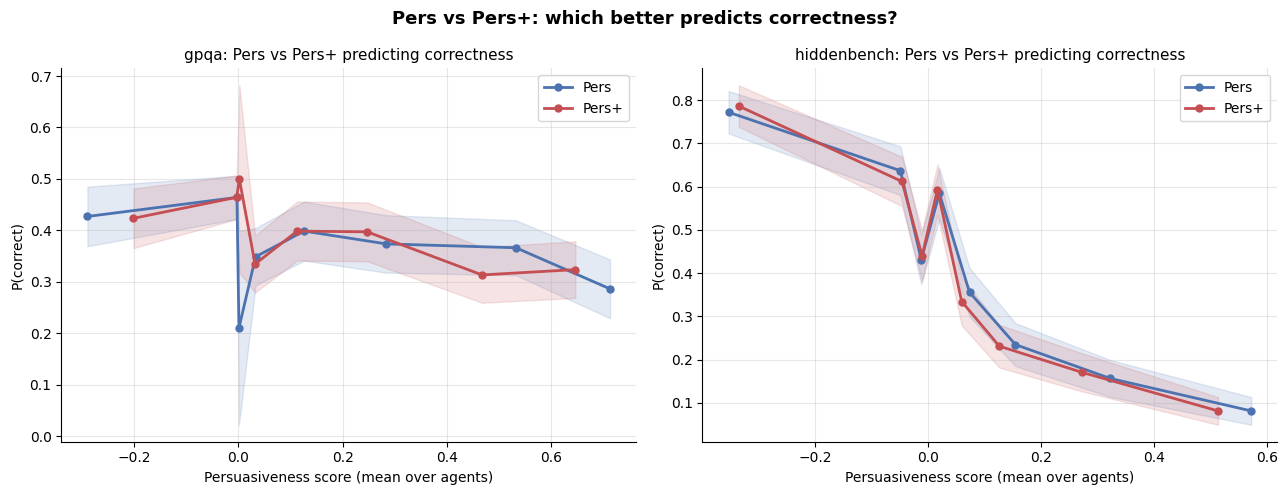

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ds in zip(axes, datasets):
    sub = rep_df[rep_df['dataset'] == ds]
    for col, label, color in [
        ('pers_mean',      'Pers',  '#4C72B0'),
        ('pers_plus_mean', 'Pers+', '#C44E52'),
    ]:
        bins = np.percentile(sub[col], np.linspace(0, 100, 9))
        bins = np.unique(bins)
        lbls = (bins[:-1] + bins[1:]) / 2
        cut = pd.cut(sub[col], bins=bins, labels=lbls)
        grp = sub.groupby(cut)['rep_correct']
        means, sems = grp.mean(), grp.sem()
        xs = means.index.astype(float)
        ax.plot(xs, means, marker='o', color=color, linewidth=2,
                markersize=5, label=label)
        ax.fill_between(xs, means-sems*1.96, means+sems*1.96,
                        color=color, alpha=0.15)
    ax.set_xlabel('Persuasiveness score (mean over agents)', fontsize=10)
    ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: Pers vs Pers+ predicting correctness', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Pers vs Pers+: which better predicts correctness?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 3 — What Makes an Agent Persuasive?

We now look for features that predict high persuasiveness **before or independent of the debate outcome**.
Variables investigated:

- **Token counts** (prompt / completion) — does verbosity correlate with influence?
- **Initial confidence** — do agents that start confident persuade more?
- **Confidence change** — does gaining/losing confidence track persuasiveness?
- **Memory window W** — does more context make an agent more persuasive?
- **Text features** — mathematical content, hedging language, assertive language, message length
- **Initial position** (majority/minority at r0) — structural advantage
- **Correlation overview** — Spearman matrix

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/3136538902.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['pers']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/3136538902.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = sub.groupby(cut)['pers']
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_22328/3136538902.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

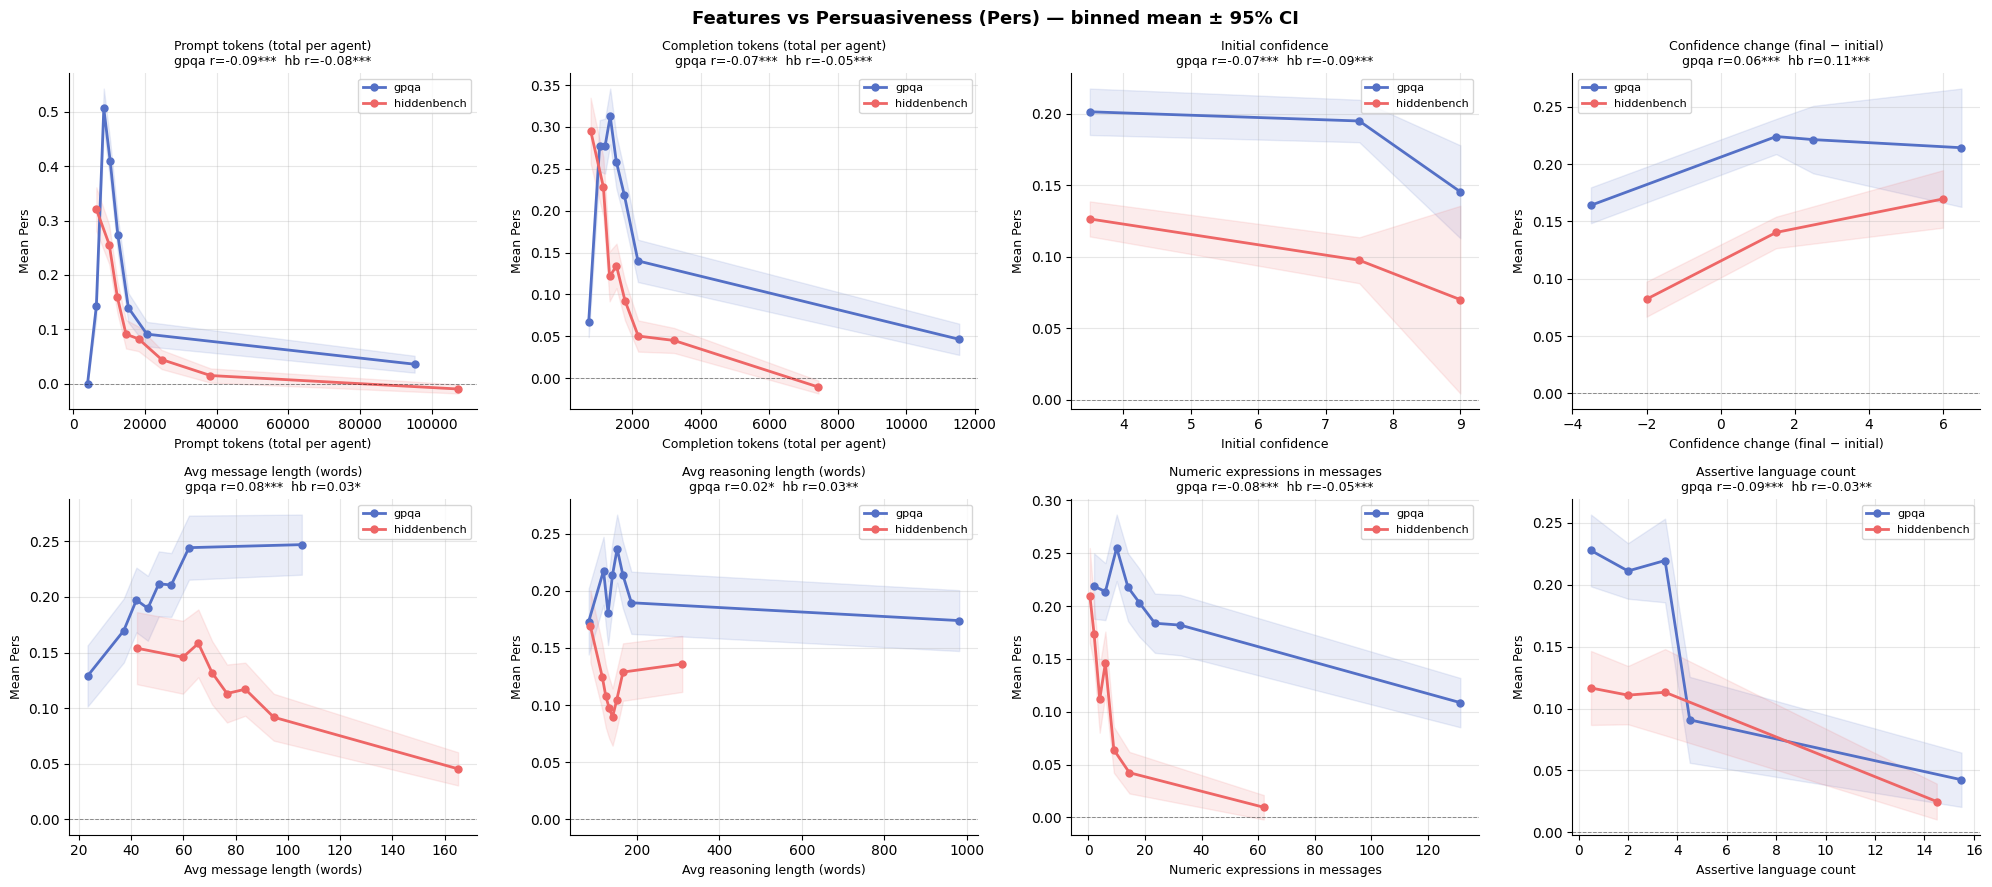

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

feature_pairs = [
    ('prompt_tokens',    'Prompt tokens (total per agent)'),
    ('completion_tokens','Completion tokens (total per agent)'),
    ('conf_r0',          'Initial confidence'),
    ('conf_delta',       'Confidence change (final − initial)'),
    ('avg_msg_len',      'Avg message length (words)'),
    ('avg_reas_len',     'Avg reasoning length (words)'),
    ('math_count',       'Numeric expressions in messages'),
    ('assert_count',     'Assertive language count'),
]

for ax, (feat, flabel) in zip(axes.flat, feature_pairs):
    for ds, color in DS_COLORS.items():
        sub = df[df['dataset'] == ds].copy()
        bins = np.percentile(sub[feat], np.linspace(0, 100, 9))
        bins = np.unique(bins)
        if len(bins) < 3:
            continue
        lbls = (bins[:-1] + bins[1:]) / 2
        cut = pd.cut(sub[feat], bins=bins, labels=lbls)
        grp = sub.groupby(cut)['pers']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 5
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=color,
                linewidth=2, markersize=5, label=ds)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                        color=color, alpha=0.12)
    r_g, p_g = sp_stats.spearmanr(df[df['dataset']=='gpqa'][feat], df[df['dataset']=='gpqa']['pers'])
    r_h, p_h = sp_stats.spearmanr(df[df['dataset']=='hiddenbench'][feat], df[df['dataset']=='hiddenbench']['pers'])
    sig_g = '***' if p_g<0.001 else '**' if p_g<0.01 else '*' if p_g<0.05 else 'ns'
    sig_h = '***' if p_h<0.001 else '**' if p_h<0.01 else '*' if p_h<0.05 else 'ns'
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xlabel(flabel, fontsize=9)
    ax.set_ylabel('Mean Pers', fontsize=9)
    ax.set_title(f'{flabel}\ngpqa r={r_g:.2f}{sig_g}  hb r={r_h:.2f}{sig_h}', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Features vs Persuasiveness (Pers) — binned mean ± 95% CI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

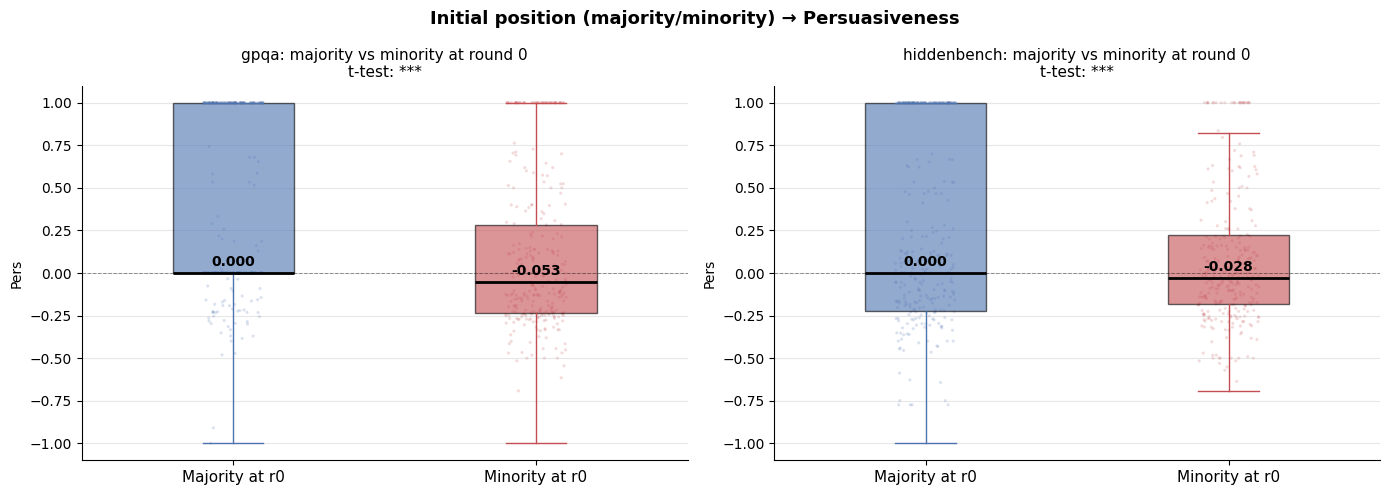

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    sub = df[df['dataset'] == ds]
    for maj, label, color in [
        (True,  'Majority at r0',  '#4C72B0'),
        (False, 'Minority at r0',  '#C44E52'),
    ]:
        vals = sub[sub['in_majority_r0'] == maj]['pers'].values
        bp = ax.boxplot(vals, positions=[0 if maj else 1], widths=0.4,
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(facecolor=color, alpha=0.6),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color),
                        flierprops=dict(marker='', alpha=0))
        jitter = np.random.uniform(-0.1, 0.1, min(len(vals), 300))
        sample = np.random.choice(vals, min(len(vals), 300), replace=False)
        ax.scatter([0 if maj else 1] + jitter, sample,
                   s=5, alpha=0.2, color=color, edgecolors='none')
        ax.text(0 if maj else 1, np.median(vals) + 0.04,
                f'{np.median(vals):.3f}', ha='center', fontsize=10, fontweight='bold')
    t, p = sp_stats.ttest_ind(
        sub[sub['in_majority_r0']==True]['pers'],
        sub[sub['in_majority_r0']==False]['pers']
    )
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns p={p:.2f}'
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Majority at r0', 'Minority at r0'], fontsize=11)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_ylabel('Pers', fontsize=10)
    ax.set_title(f'{ds}: majority vs minority at round 0\nt-test: {sig}', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Initial position (majority/minority) → Persuasiveness',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

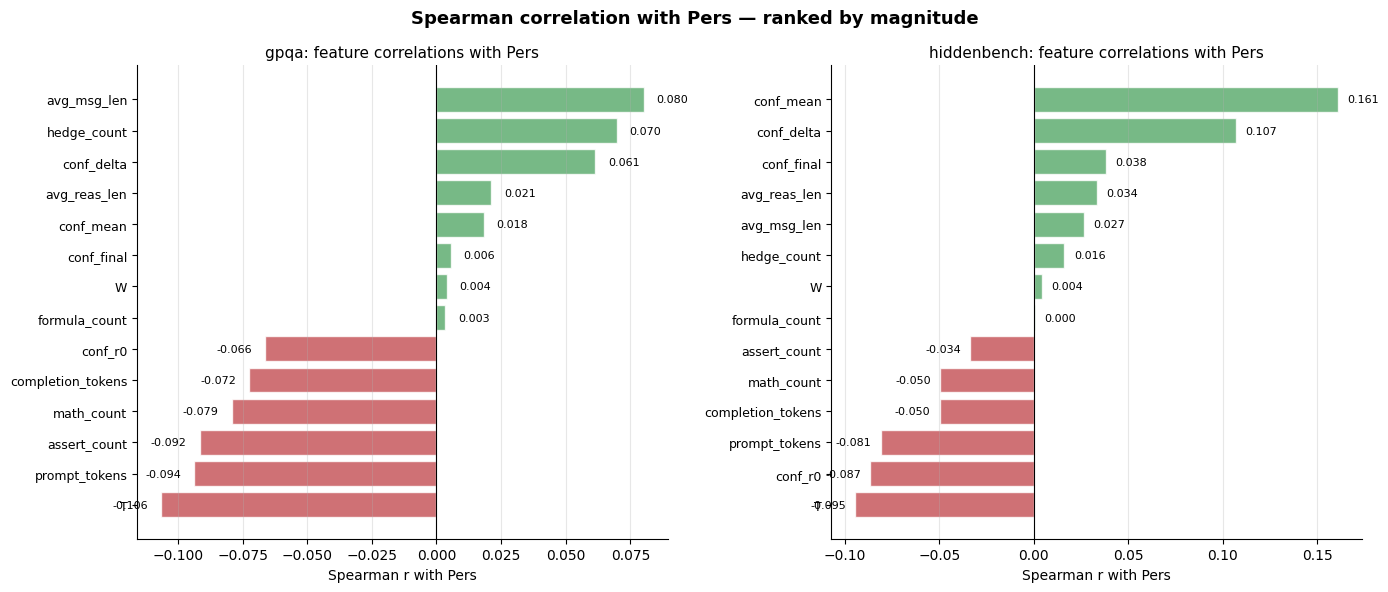

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_feats = [
    'W', 'T', 'conf_r0', 'conf_final', 'conf_delta', 'conf_mean',
    'prompt_tokens', 'completion_tokens',
    'math_count', 'formula_count', 'hedge_count', 'assert_count',
    'avg_msg_len', 'avg_reas_len',
    'pers', 'pers_plus',
]

for ax, ds in zip(axes, datasets):
    sub = df[df['dataset'] == ds][corr_feats].dropna()
    corr = sub.corr(method='spearman')
    pers_row = corr['pers'].drop(['pers', 'pers_plus']).sort_values()
    colors = ['#C44E52' if v < 0 else '#55A868' for v in pers_row]
    ax.barh(range(len(pers_row)), pers_row.values, color=colors, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(pers_row)))
    ax.set_yticklabels(pers_row.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    for i, v in enumerate(pers_row.values):
        ax.text(v + (0.005 if v >= 0 else -0.005), i,
                f'{v:.3f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=8)
    ax.set_xlabel('Spearman r with Pers', fontsize=10)
    ax.set_title(f'{ds}: feature correlations with Pers', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Spearman correlation with Pers — ranked by magnitude',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Text content before a flip

We look at the **last message an agent wrote before flipping** vs messages where it stayed.
This isolates what argumentative style precedes a persuasion event.

Pre-flip observations: 89504
Flip rate: 0.196


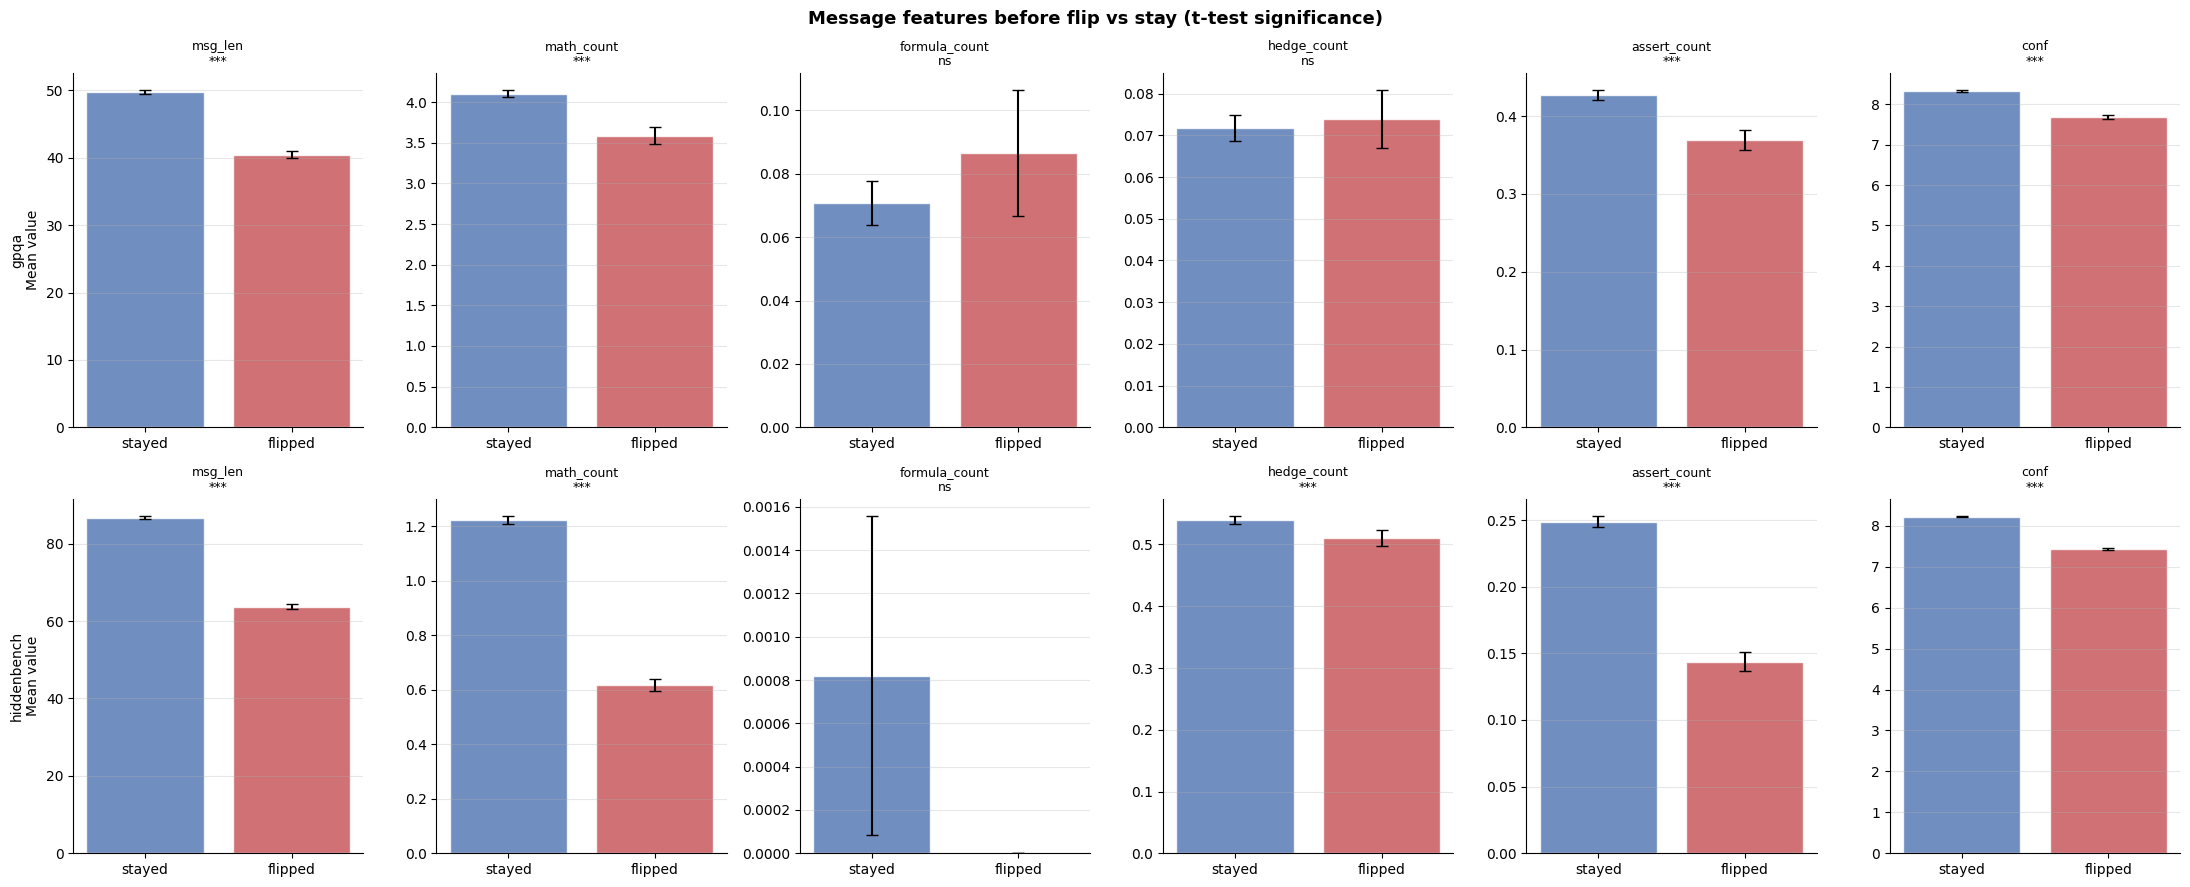

In [35]:
pre_flip_records = []
for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys:
            continue
        dataset = ds_key
        for rep in d['repetitions']:
            traj = rep['trajectory']
            T = len(traj)
            N = len(traj[0]['phase_b'])
            for a in range(N):
                for t in range(T - 1):
                    ag    = traj[t]['phase_b'][a]
                    ag_nx = traj[t+1]['phase_b'][a]
                    msg = ag.get('message', '')
                    did_flip = ag['vote'] != ag_nx['vote']
                    toks = msg.split()
                    pre_flip_records.append({
                        'W': w, 'qid': qid, 'dataset': dataset,
                        'round': t,
                        'did_flip_next': did_flip,
                        'msg_len':      len(toks),
                        'math_count':   len(re.findall(r'\d+\.?\d*', msg)),
                        'formula_count':len(re.findall(r'[=<>≈±×÷∑∫√]', msg)),
                        'hedge_count':  len(re.findall(
                            r'\b(however|although|but|yet|while|though|uncertain|maybe|perhaps|possibly)\b',
                            msg, re.I)),
                        'assert_count': len(re.findall(
                            r'\b(therefore|thus|clearly|obviously|must|certainly|definitely|conclude)\b',
                            msg, re.I)),
                        'conf': ag.get('confidence') or 0,
                    })

pf = pd.DataFrame(pre_flip_records)
print(f'Pre-flip observations: {len(pf)}')
print(f'Flip rate: {pf["did_flip_next"].mean():.3f}')

text_feats = ['msg_len', 'math_count', 'formula_count', 'hedge_count', 'assert_count', 'conf']

fig, axes = plt.subplots(2, len(text_feats), figsize=(22, 9))

for row, ds in enumerate(datasets):
    sub = pf[pf['dataset'] == ds]
    for ax, feat in zip(axes[row], text_feats):
        flip_vals   = sub[sub['did_flip_next']==True][feat]
        nflip_vals  = sub[sub['did_flip_next']==False][feat]
        t, p = sp_stats.ttest_ind(flip_vals, nflip_vals)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns'
        for vals, label, color in [
            (nflip_vals, 'stayed', '#4C72B0'),
            (flip_vals,  'flipped', '#C44E52'),
        ]:
            ax.bar(label, vals.mean(), color=color, alpha=0.8, edgecolor='white')
            ax.errorbar(label, vals.mean(), yerr=vals.sem()*1.96,
                        fmt='none', color='black', capsize=4)
        ax.set_title(f'{feat}\n{sig}', fontsize=9)
        ax.set_ylabel('Mean' if feat == text_feats[0] else '', fontsize=9)
        if row == 0:
            ax.set_xlabel('')
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    axes[row, 0].set_ylabel(f'{ds}\nMean value', fontsize=10)

fig.suptitle('Message features before flip vs stay (t-test significance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Persuasiveness by W — final summary

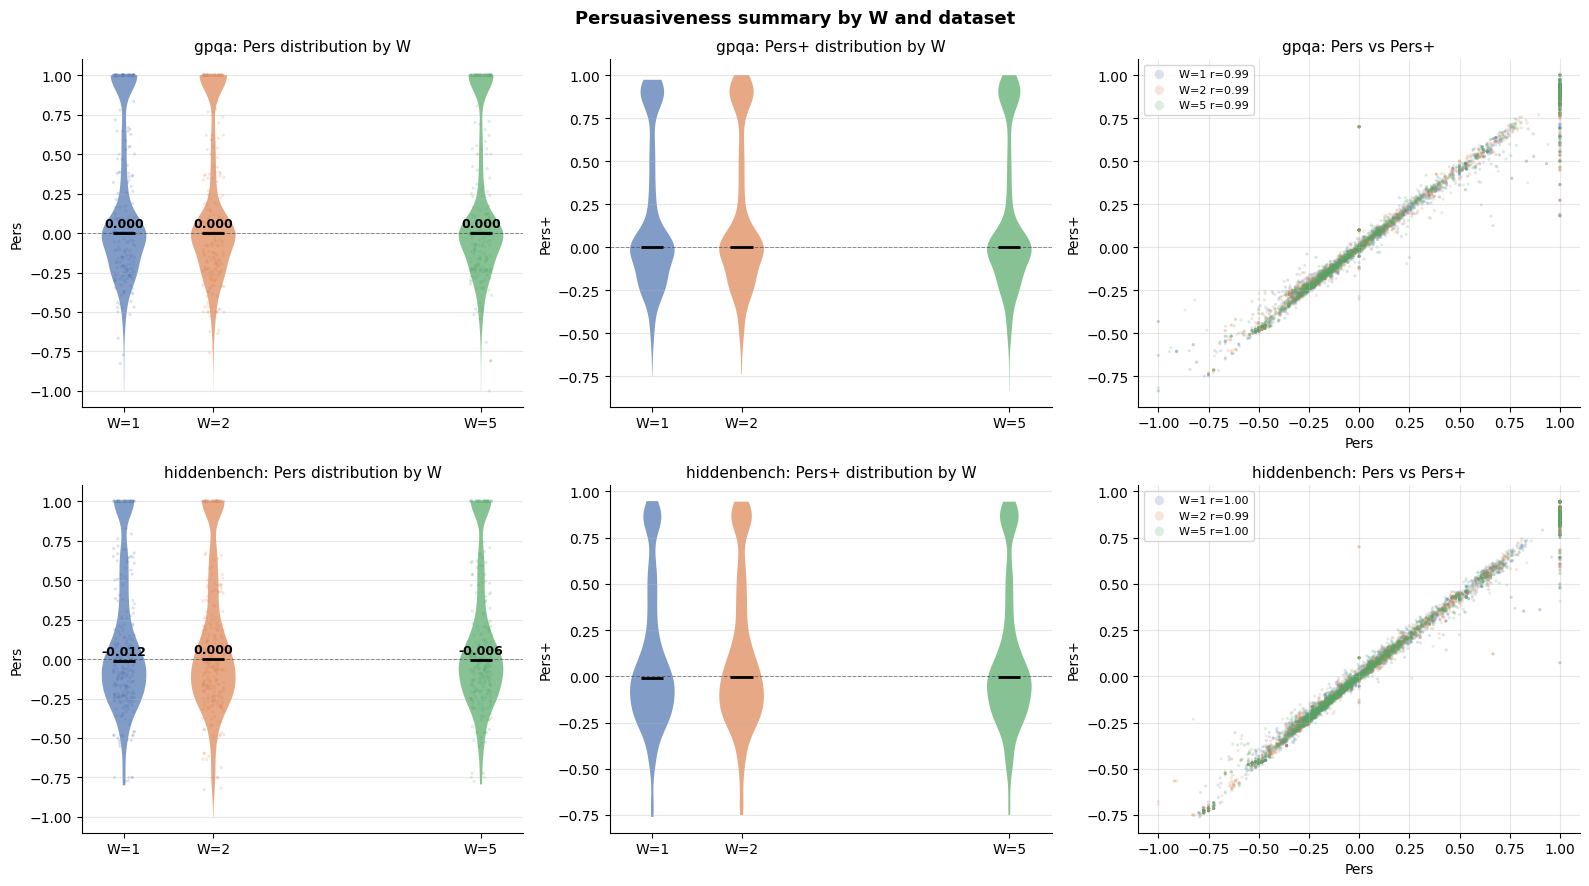

Summary table:


pers               pers_plus              
                mean median    std      mean median    std
dataset     W                                             
gpqa        1  0.198  0.000  0.486     0.173  0.000  0.433
            2  0.204  0.000  0.495     0.179  0.000  0.441
            5  0.197  0.000  0.486     0.174  0.000  0.436
hiddenbench 1  0.118 -0.012  0.457     0.095 -0.009  0.397
            2  0.125  0.000  0.473     0.104 -0.003  0.411
            5  0.116 -0.006  0.454     0.097 -0.004  0.395

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]

    ax = axes[row, 0]
    data_by_w = [sub[sub['W']==w]['pers'].dropna().values for w in W_VALUES]
    parts = ax.violinplot(data_by_w, positions=W_VALUES, showmedians=True, showextrema=False)
    for pc, w in zip(parts['bodies'], W_VALUES):
        pc.set_facecolor(W_COLORS[w]); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    for w, vals in zip(W_VALUES, data_by_w):
        jitter = np.random.uniform(-0.12, 0.12, min(len(vals), 300))
        sample = np.random.choice(vals, min(len(vals), 300), replace=False)
        ax.scatter(w + jitter, sample, s=5, alpha=0.2, color=W_COLORS[w], edgecolors='none')
        ax.text(w, np.median(vals)+0.04, f'{np.median(vals):.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xticks(W_VALUES); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_ylabel('Pers', fontsize=10)
    ax.set_title(f'{ds}: Pers distribution by W', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    data_by_w = [sub[sub['W']==w]['pers_plus'].dropna().values for w in W_VALUES]
    parts = ax.violinplot(data_by_w, positions=W_VALUES, showmedians=True, showextrema=False)
    for pc, w in zip(parts['bodies'], W_VALUES):
        pc.set_facecolor(W_COLORS[w]); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xticks(W_VALUES); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_ylabel('Pers+', fontsize=10)
    ax.set_title(f'{ds}: Pers+ distribution by W', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for w in W_VALUES:
        subw = sub[sub['W']==w]
        r, p = sp_stats.spearmanr(subw['pers'], subw['pers_plus'])
        ax.scatter(subw['pers'], subw['pers_plus'],
                   color=W_COLORS[w], s=5, alpha=0.2, edgecolors='none',
                   label=f'W={w} r={r:.2f}')
    ax.set_xlabel('Pers', fontsize=10); ax.set_ylabel('Pers+', fontsize=10)
    ax.set_title(f'{ds}: Pers vs Pers+', fontsize=11)
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness summary by W and dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Summary table:')
display(
    df.groupby(['dataset', 'W'])[['pers', 'pers_plus']]
    .agg(['mean', 'median', 'std'])
    .round(3)
)

---
# Part 4 — Confound Analysis: Why Does High Pers Predict Lower Accuracy?

We found a strong negative correlation between Pers and accuracy (r≈−0.12 gpqa, r≈−0.37 hiddenbench).
Two candidate confounds:

1. **Question difficulty** — hard questions generate more disagreement and more flip events,
   inflating Pers, but are also inherently harder to answer correctly. If this drives the
   effect, the relationship should disappear *within* a single question.
2. **Debate length T** — longer debates accumulate more persuasion opportunities in the
   denominator, which can suppress the score; but longer debates also tend to occur on harder
   questions. We stratify by T to check.

We also flag the concern about `conf_delta` as a feature: since confidence is part of the
score formula, its correlation with Pers is partially mechanistic and should not be
interpreted as an independent driver.

In [37]:
from collections import Counter

def vote_config(votes):
    counts = sorted(Counter(votes).values(), reverse=True)
    return '-'.join(map(str, counts))

df['cfg_r0'] = None
df['n_unique_r0'] = None

cfg_map = {}
for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys: continue
        for rep_idx, rep in enumerate(d['repetitions']):
            traj = rep['trajectory']
            votes_r0 = [traj[0]['phase_b'][a]['vote'] for a in range(len(traj[0]['phase_b']))]
            cfg = vote_config(votes_r0)
            n_u = len(set(votes_r0))
            for a in range(len(traj[0]['phase_b'])):
                cfg_map[(w, ds_key, qid, rep_idx, a)] = (cfg, n_u)

df['cfg_r0']     = df.apply(lambda r: cfg_map.get((r['W'], r['dataset'], r['qid'], r['rep'], r['agent']), (None,None))[0], axis=1)
df['n_unique_r0']= df.apply(lambda r: cfg_map.get((r['W'], r['dataset'], r['qid'], r['rep'], r['agent']), (None,None))[1], axis=1)

rep_df2 = df.groupby(['dataset','W','qid','rep']).agg(
    pers_mean=('pers','mean'),
    pers_max=('pers','max'),
    rep_correct=('rep_correct','first'),
    rep_converged=('rep_converged','first'),
    T=('T','first'),
    cfg_r0=('cfg_r0','first'),
    n_unique_r0=('n_unique_r0','first'),
).reset_index()

q_acc = rep_df2.groupby(['dataset','qid'])['rep_correct'].mean().reset_index()
q_acc.columns = ['dataset','qid','q_accuracy']
rep_df2 = rep_df2.merge(q_acc, on=['dataset','qid'])

print('Vote configs observed:')
display(df.groupby('cfg_r0')['pers'].agg(['count','mean','median']).round(3))

print('\nPers and accuracy by config + dataset:')
cfg_summary = df.groupby(['dataset','cfg_r0'])['pers'].agg(['mean','median','count']).round(3)
cfg_acc = rep_df2.groupby(['dataset','cfg_r0'])['rep_correct'].mean().round(3)
display(cfg_summary.join(cfg_acc).rename(columns={'rep_correct':'accuracy'}))

Vote configs observed:


,count,mean,median
cfg_r0,,,
1-1-1-1,144,0.030,-0.055
2-1-1,3504,0.091,-0.026
2-2,4444,0.103,-0.040
3-1,7464,0.277,0.083
4,2444,0.012,0.000



Pers and accuracy by config + dataset:


mean  median  count  accuracy
dataset     cfg_r0                                 
gpqa        1-1-1-1  0.028  -0.050    132     0.212
            2-1-1    0.125  -0.023   1800     0.338
            2-2      0.133  -0.022   1796     0.414
            3-1      0.404   0.362   3252     0.357
            4        0.007   0.000   2020     0.481
hiddenbench 1-1-1-1  0.048  -0.100     12     0.667
            2-1-1    0.055  -0.028   1704     0.585
            2-2      0.082  -0.045   2648     0.363
            3-1      0.179   0.022   4212     0.377
            4        0.035   0.000    424     0.245

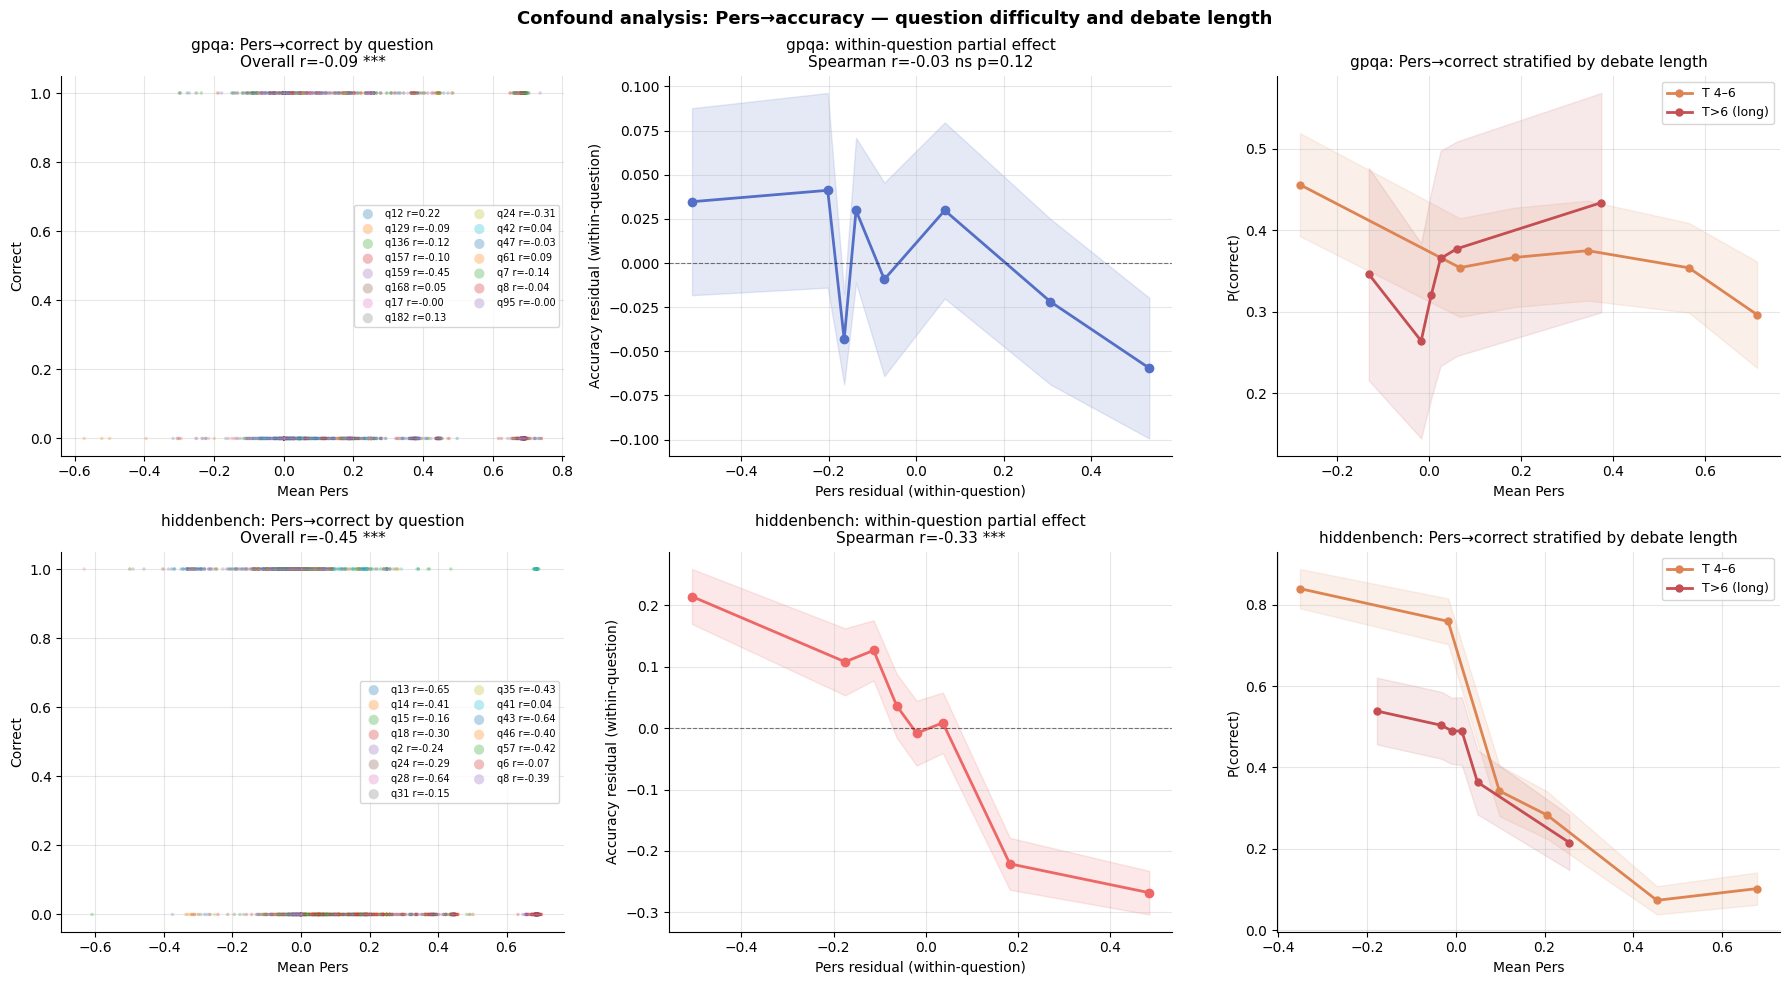

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, ds in enumerate(datasets):
    sub   = rep_df2[rep_df2['dataset']==ds]
    sub_a = df[df['dataset']==ds]
    color = DS_COLORS[ds]
    qids  = sorted(sub['qid'].unique())
    cmap  = plt.cm.tab10

    # A: raw scatter colored by question
    ax = axes[row, 0]
    for i, qid in enumerate(qids):
        sq = sub[sub['qid']==qid]
        r_q, _ = sp_stats.spearmanr(sq['pers_mean'], sq['rep_correct'])
        ax.scatter(sq['pers_mean'], sq['rep_correct'].astype(float),
                   color=cmap(i % 10), s=6, alpha=0.3, edgecolors='none',
                   label=f'q{qid} r={r_q:.2f}')
    r_all, p_all = sp_stats.spearmanr(sub['pers_mean'], sub['rep_correct'])
    sig = '***' if p_all<0.001 else '**' if p_all<0.01 else '*' if p_all<0.05 else 'ns'
    ax.set_xlabel('Mean Pers', fontsize=10); ax.set_ylabel('Correct', fontsize=10)
    ax.set_title(f'{ds}: Pers→correct by question\nOverall r={r_all:.2f} {sig}', fontsize=11)
    ax.legend(fontsize=7, markerscale=3, ncol=2)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # B: within-question partial (residuals)
    ax = axes[row, 1]
    sub2 = sub.copy()
    sub2['pers_resid']    = sub2['pers_mean'] - sub2.groupby('qid')['pers_mean'].transform('mean')
    sub2['correct_resid'] = sub2['rep_correct'].astype(float) - sub2.groupby('qid')['rep_correct'].transform('mean')
    bins = np.percentile(sub2['pers_resid'], np.linspace(0,100,9))
    bins = np.unique(bins)
    if len(bins) >= 3:
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(sub2['pers_resid'], bins=bins, labels=lbls)
        grp  = sub2.groupby(cut, observed=False)['correct_resid']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=color, alpha=0.15)
    r2, p2 = sp_stats.spearmanr(sub2['pers_resid'], sub2['correct_resid'])
    sig2 = '***' if p2<0.001 else '**' if p2<0.01 else '*' if p2<0.05 else f'ns p={p2:.2f}'
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Pers residual (within-question)', fontsize=10)
    ax.set_ylabel('Accuracy residual (within-question)', fontsize=10)
    ax.set_title(f'{ds}: within-question partial effect\nSpearman r={r2:.2f} {sig2}', fontsize=11)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # C: stratified by debate length
    ax = axes[row, 2]
    for t_mask, t_color, t_label in [
        (sub['T'] <= 3,               '#55A868', 'T≤3 (short)'),
        ((sub['T']>3)&(sub['T']<=6),  '#DD8452', 'T 4–6'),
        (sub['T'] > 6,                '#C44E52', 'T>6 (long)'),
    ]:
        subT = sub[t_mask]
        if len(subT) < 10: continue
        bins = np.percentile(subT['pers_mean'], np.linspace(0,100,7))
        bins = np.unique(bins)
        if len(bins) < 3: continue
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(subT['pers_mean'], bins=bins, labels=lbls)
        grp  = subT.groupby(cut, observed=False)['rep_correct']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=t_color, linewidth=2, markersize=5, label=t_label)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=t_color, alpha=0.12)
    ax.set_xlabel('Mean Pers', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: Pers→correct stratified by debate length', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Confound analysis: Pers→accuracy — question difficulty and debate length',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 5 — Persuasiveness by Starting Vote Configuration

With N=4 agents the possible initial vote splits are:
- **4-0**: all agents agree from round 0 — no persuasion possible
- **3-1**: one dissenter vs three-agent majority
- **2-2**: perfectly balanced split
- **2-1-1**: two agents agree, two each hold unique positions
- **1-1-1-1**: maximum diversity, all agents hold different positions

We ask: how does the starting configuration affect Pers, accuracy, and convergence?

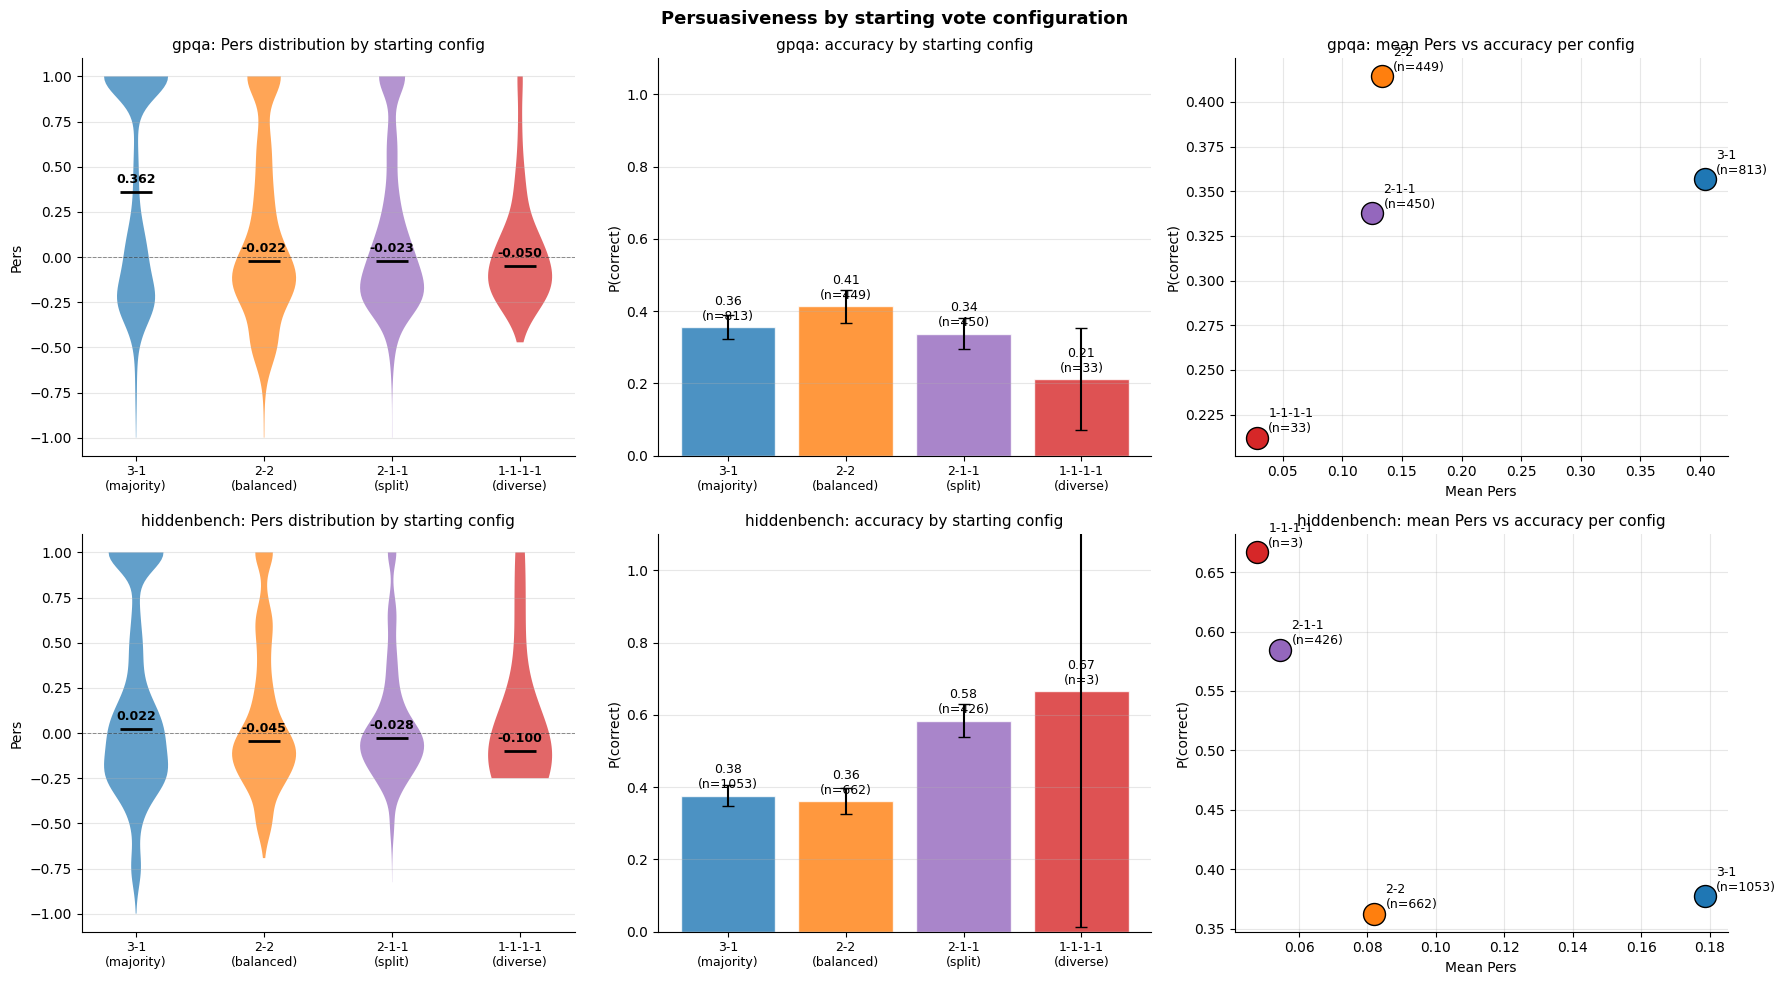

In [39]:
config_order  = ['3-1','2-2','2-1-1','1-1-1-1']
config_colors = {'4-0':'#2ca02c','3-1':'#1f77b4','2-2':'#ff7f0e','2-1-1':'#9467bd','1-1-1-1':'#d62728'}
config_labels = {
    '4-0':   '4-0\n(unanimous)',
    '3-1':   '3-1\n(majority)',
    '2-2':   '2-2\n(balanced)',
    '2-1-1': '2-1-1\n(split)',
    '1-1-1-1':'1-1-1-1\n(diverse)',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, ds in enumerate(datasets):
    sub_a = df[df['dataset']==ds]
    sub_r = rep_df2[rep_df2['dataset']==ds]
    present = [c for c in config_order if c in sub_a['cfg_r0'].values]

    # A: Pers violin by config
    ax = axes[row, 0]
    data_by_cfg = [sub_a[sub_a['cfg_r0']==c]['pers'].dropna().values for c in present]
    parts = ax.violinplot(data_by_cfg, positions=range(len(present)),
                          showmedians=True, showextrema=False)
    for pc, c in zip(parts['bodies'], present):
        pc.set_facecolor(config_colors.get(c,'gray')); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    for i, (c, vals) in enumerate(zip(present, data_by_cfg)):
        ax.text(i, np.median(vals)+0.05, f'{np.median(vals):.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels([config_labels.get(c,c) for c in present], fontsize=9)
    ax.set_ylabel('Pers', fontsize=10)
    ax.set_title(f'{ds}: Pers distribution by starting config', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # B: accuracy by config
    ax = axes[row, 1]
    cfg_stats = sub_r.groupby('cfg_r0')['rep_correct'].agg(['mean','sem','count']).reindex(present)
    ax.bar(range(len(present)), cfg_stats['mean'],
           color=[config_colors.get(c,'gray') for c in present], alpha=0.8, edgecolor='white')
    ax.errorbar(range(len(present)), cfg_stats['mean'], yerr=cfg_stats['sem']*1.96,
                fmt='none', color='black', capsize=4)
    for i, (acc, n) in enumerate(zip(cfg_stats['mean'], cfg_stats['count'])):
        ax.text(i, acc+0.02, f'{acc:.2f}\n(n={n:.0f})', ha='center', fontsize=9)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels([config_labels.get(c,c) for c in present], fontsize=9)
    ax.set_ylabel('P(correct)', fontsize=10); ax.set_ylim(0, 1.1)
    ax.set_title(f'{ds}: accuracy by starting config', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # C: mean Pers vs accuracy scatter per config
    ax = axes[row, 2]
    for c in present:
        p_val = sub_a[sub_a['cfg_r0']==c]['pers'].mean()
        a_val = sub_r[sub_r['cfg_r0']==c]['rep_correct'].mean()
        n     = len(sub_r[sub_r['cfg_r0']==c])
        ax.scatter(p_val, a_val, color=config_colors.get(c,'gray'),
                   s=250, zorder=5, edgecolors='black', linewidths=1)
        ax.annotate(f'{config_labels.get(c,c).split(chr(10))[0]}\n(n={n})',
                    (p_val, a_val), textcoords='offset points', xytext=(8,4), fontsize=9)
    ax.set_xlabel('Mean Pers', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: mean Pers vs accuracy per config', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Persuasiveness by starting vote configuration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 6 — Why Does High Pers Predict Lower Accuracy?

We test three concrete hypotheses:

1. **Wrong agent dominates** — the top-Pers agent happens to hold the wrong answer, efficiently converting everyone else to it
2. **Flips go the wrong way** — in high-Pers debates, persuasion events disproportionately move agents *away* from the correct answer
3. **Capitulation vs conviction** — agents that flip under high-Pers conditions do so with a confidence *drop* (social capitulation) rather than a genuine update

We synthesise with a 2×2: initial majority correct × Pers level.

In [40]:
from collections import Counter

flip_records2 = []
rep_records2  = []

for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys: continue
        gt      = d['ground_truth']
        dataset = ds_key
        for rep_idx, rep in enumerate(d['repetitions']):
            traj   = rep['trajectory']
            T      = len(traj)
            N      = len(traj[0]['phase_b'])
            p_scores = pers_metric.score(rep)

            votes_r0    = [traj[0]['phase_b'][a]['vote'] for a in range(N)]
            votes_final = [traj[-1]['phase_b'][a]['vote'] for a in range(N)]
            majority_r0    = max(set(votes_r0),    key=votes_r0.count)
            majority_final = max(set(votes_final), key=votes_final.count)
            init_majority_correct = majority_r0 == gt
            rep_correct   = majority_final == gt
            rep_converged = len(set(votes_final)) == 1
            top_agent     = int(np.argmax(p_scores))
            top_pers      = p_scores[top_agent]
            top_correct_r0 = traj[0]['phase_b'][top_agent]['vote'] == gt
            n_correct_r0   = sum(traj[0]['phase_b'][a]['vote'] == gt for a in range(N))

            rep_records2.append({
                'W': w, 'qid': qid, 'dataset': dataset, 'rep': rep_idx,
                'pers_mean': np.mean(p_scores), 'pers_max': top_pers,
                'T': T, 'rep_correct': rep_correct, 'rep_converged': rep_converged,
                'init_majority_correct': init_majority_correct,
                'top_agent_correct_r0': top_correct_r0,
                'n_correct_r0': n_correct_r0,
            })

            for a in range(N):
                for t in range(T - 1):
                    v_before = traj[t]['phase_b'][a]['vote']
                    v_after  = traj[t+1]['phase_b'][a]['vote']
                    if v_before == v_after: continue
                    c_before = traj[t]['phase_b'][a].get('confidence') or 0
                    c_after  = traj[t+1]['phase_b'][a].get('confidence') or 0
                    flip_records2.append({
                        'W': w, 'qid': qid, 'dataset': dataset, 'rep': rep_idx,
                        'agent': a, 'round': t,
                        'rep_pers_mean': np.mean(p_scores),
                        'flip_toward_correct': v_after == gt,
                        'flip_away_correct':   v_before == gt,
                        'conf_before': c_before, 'conf_after': c_after,
                        'conf_change': c_after - c_before,
                        'rep_correct': rep_correct,
                        'init_majority_correct': init_majority_correct,
                    })

rep_df3  = pd.DataFrame(rep_records2)
flip_df3 = pd.DataFrame(flip_records2)
print(f'Rep rows: {len(rep_df3)}  |  Flip rows: {len(flip_df3)}')
print('\nFlip direction summary:')
display(flip_df3.groupby('dataset')[['flip_toward_correct','flip_away_correct']].mean().round(3))

Rep rows: 4500  |  Flip rows: 17555

Flip direction summary:


,flip_toward_correct,flip_away_correct
dataset,,
gpqa,0.356,0.332
hiddenbench,0.418,0.211


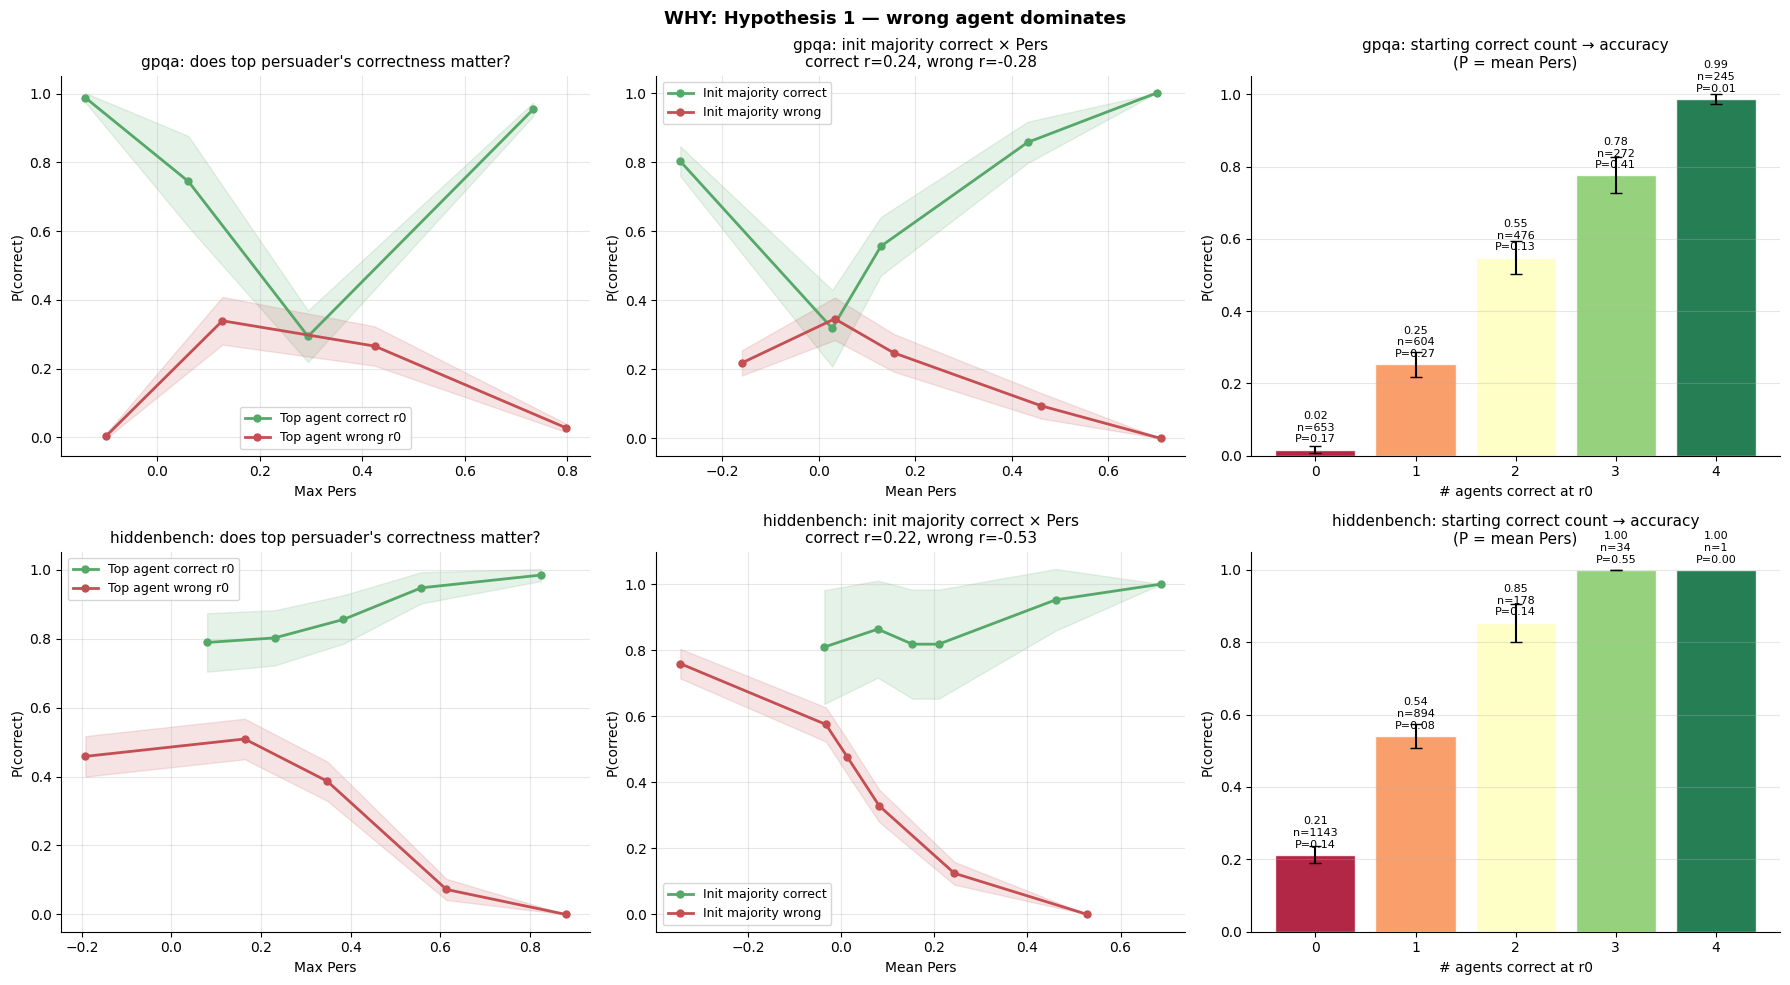

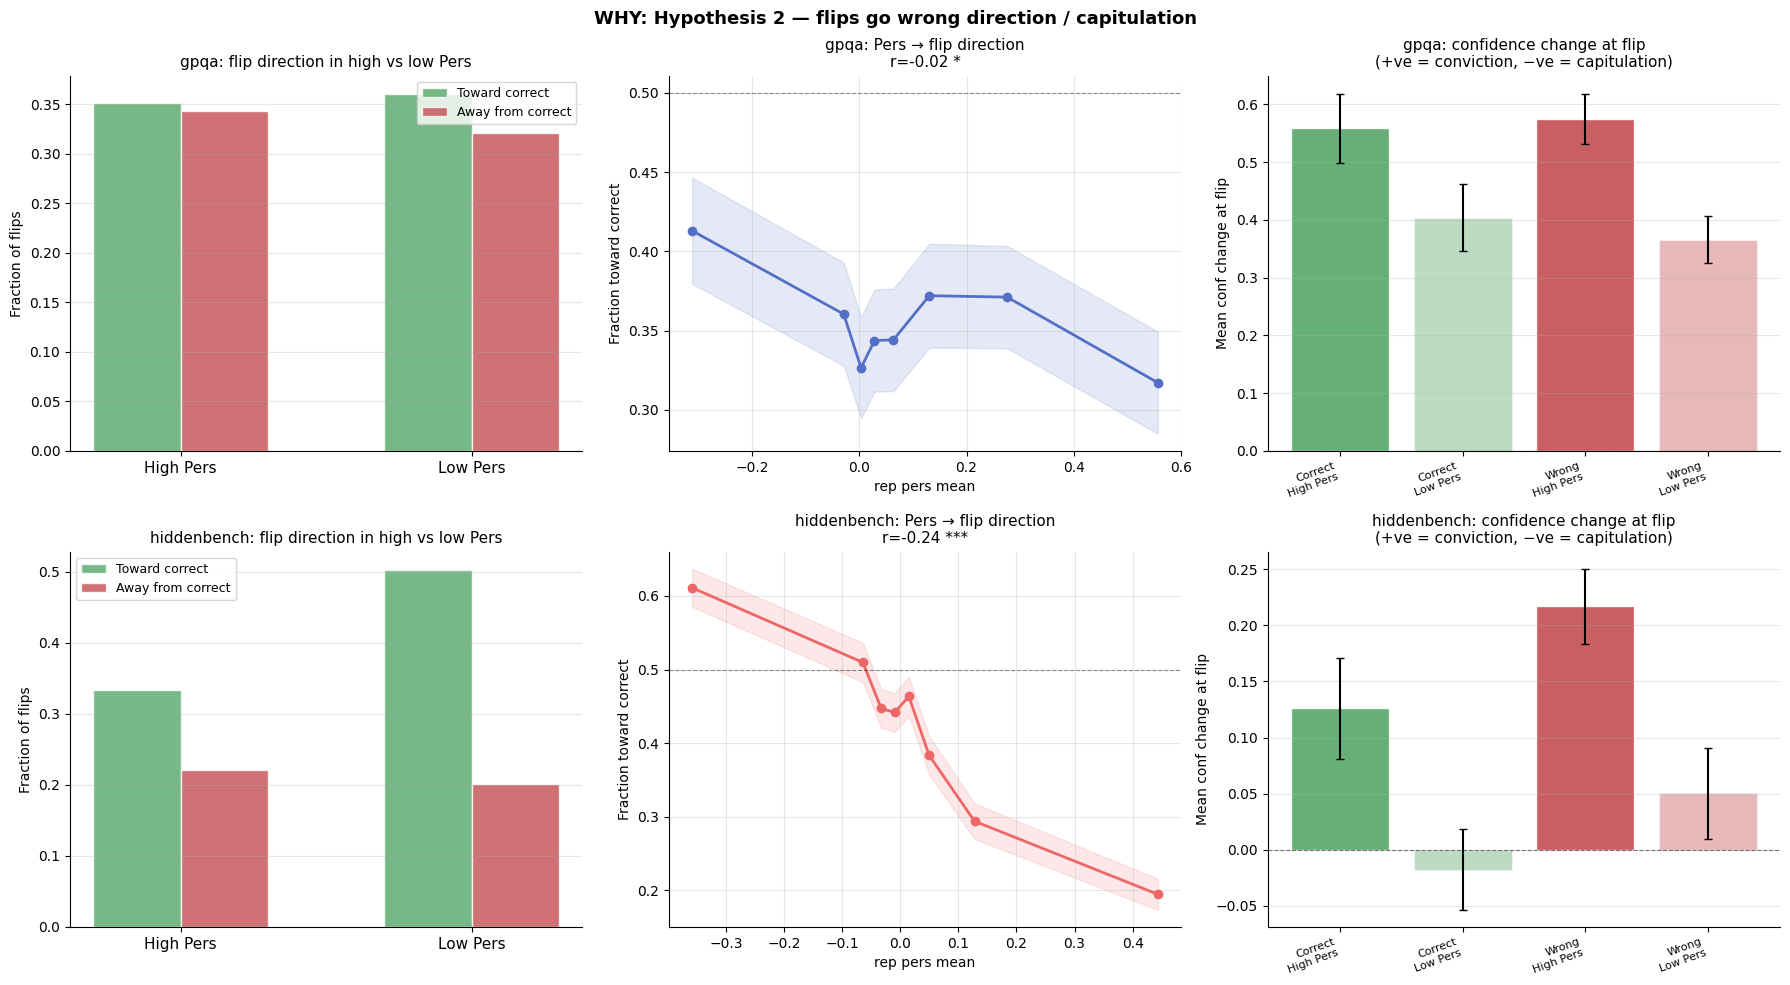

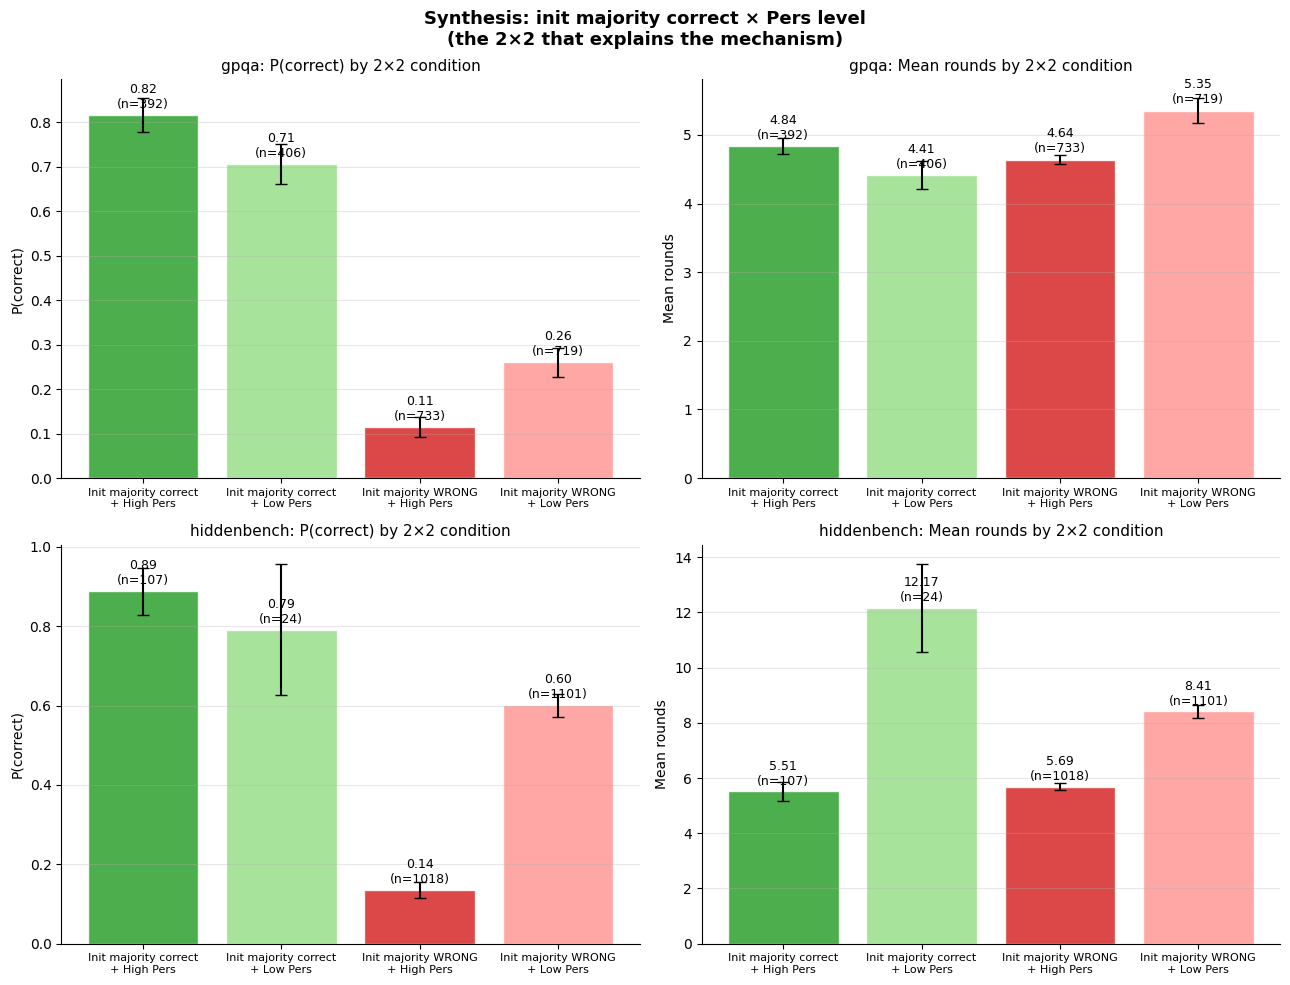


=== KEY NUMBERS ===

gpqa:
  Init majority correct + High Pers: acc=0.816  T=4.8  n=392
  Init majority correct + Low Pers: acc=0.707  T=4.4  n=406
  Init majority WRONG + High Pers: acc=0.115  T=4.6  n=733
  Init majority WRONG + Low Pers: acc=0.260  T=5.4  n=719

hiddenbench:
  Init majority correct + High Pers: acc=0.888  T=5.5  n=107
  Init majority correct + Low Pers: acc=0.792  T=12.2  n=24
  Init majority WRONG + High Pers: acc=0.136  T=5.7  n=1018
  Init majority WRONG + Low Pers: acc=0.601  T=8.4  n=1101


In [41]:
def binned_why(ax, sub, xcol, ycol, color, n_bins=8, ylabel='', title='', hline=None):
    bins = np.percentile(sub[xcol], np.linspace(0,100,n_bins+1))
    bins = np.unique(bins)
    if len(bins) < 3: return
    lbls = (bins[:-1]+bins[1:])/2
    cut  = pd.cut(sub[xcol], bins=bins, labels=lbls)
    grp  = sub.groupby(cut, observed=False)[ycol]
    means, sems, ns = grp.mean(), grp.sem(), grp.count()
    valid = ns >= 3
    xs = means.index.astype(float)[valid]
    ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
    ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=color, alpha=0.15)
    r, p = sp_stats.spearmanr(sub[xcol], sub[ycol])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns p={p:.2f}'
    if hline is not None:
        ax.axhline(hline, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel(xcol.replace('_',' '), fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{title}\nr={r:.2f} {sig}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# --- Plot A: wrong agent dominates ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub   = rep_df3[rep_df3['dataset']==ds]
    sub_f = flip_df3[flip_df3['dataset']==ds]
    color = DS_COLORS[ds]

    ax = axes[row, 0]
    for correct, c, label in [(True,'#55A868','Top agent correct r0'),(False,'#C44E52','Top agent wrong r0')]:
        vals = sub[sub['top_agent_correct_r0']==correct]
        if len(vals) < 10: continue
        bins = np.percentile(vals['pers_max'], np.linspace(0,100,7)); bins=np.unique(bins)
        if len(bins)<3: continue
        lbls=(bins[:-1]+bins[1:])/2
        cut=pd.cut(vals['pers_max'],bins=bins,labels=lbls)
        grp=vals.groupby(cut,observed=False)['rep_correct']
        means,sems,ns=grp.mean(),grp.sem(),grp.count()
        valid=ns>=3; xs=means.index.astype(float)[valid]
        ax.plot(xs,means[valid],marker='o',color=c,linewidth=2,markersize=5,label=label)
        ax.fill_between(xs,(means-sems*1.96)[valid],(means+sems*1.96)[valid],color=c,alpha=0.15)
    ax.set_xlabel('Max Pers', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: does top persuader\'s correctness matter?', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    for correct, c, label in [(True,'#55A868','Init majority correct'),(False,'#C44E52','Init majority wrong')]:
        vals = sub[sub['init_majority_correct']==correct]
        if len(vals) < 10: continue
        bins = np.percentile(vals['pers_mean'], np.linspace(0,100,7)); bins=np.unique(bins)
        if len(bins)<3: continue
        lbls=(bins[:-1]+bins[1:])/2
        cut=pd.cut(vals['pers_mean'],bins=bins,labels=lbls)
        grp=vals.groupby(cut,observed=False)['rep_correct']
        means,sems,ns=grp.mean(),grp.sem(),grp.count()
        valid=ns>=3; xs=means.index.astype(float)[valid]
        ax.plot(xs,means[valid],marker='o',color=c,linewidth=2,markersize=5,label=label)
        ax.fill_between(xs,(means-sems*1.96)[valid],(means+sems*1.96)[valid],color=c,alpha=0.15)
    r1,p1=sp_stats.spearmanr(sub[sub['init_majority_correct']]['pers_mean'],sub[sub['init_majority_correct']]['rep_correct'])
    r2,p2=sp_stats.spearmanr(sub[~sub['init_majority_correct']]['pers_mean'],sub[~sub['init_majority_correct']]['rep_correct'])
    ax.set_xlabel('Mean Pers', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: init majority correct × Pers\ncorrect r={r1:.2f}, wrong r={r2:.2f}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    nc_acc  = sub.groupby('n_correct_r0')['rep_correct'].agg(['mean','sem','count'])
    nc_pers = sub.groupby('n_correct_r0')['pers_mean'].mean()
    ax.bar(nc_acc.index, nc_acc['mean'],
           color=[plt.cm.RdYlGn(v/4) for v in nc_acc.index], alpha=0.85, edgecolor='white')
    ax.errorbar(nc_acc.index, nc_acc['mean'], yerr=nc_acc['sem']*1.96,
                fmt='none', color='black', capsize=4)
    for i_idx, idx in enumerate(nc_acc.index):
        ax.text(idx, nc_acc.loc[idx,'mean']+0.02,
                f'{nc_acc.loc[idx,"mean"]:.2f}\nn={nc_acc.loc[idx,"count"]:.0f}\nP={nc_pers[idx]:.2f}',
                ha='center', fontsize=8)
    ax.set_xlabel('# agents correct at r0', fontsize=10)
    ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: starting correct count → accuracy\n(P = mean Pers)', fontsize=11)
    ax.set_xticks(nc_acc.index)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('WHY: Hypothesis 1 — wrong agent dominates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot B: flip direction & capitulation ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub_f = flip_df3[flip_df3['dataset']==ds].copy()
    color = DS_COLORS[ds]
    med   = sub_f['rep_pers_mean'].median()
    sub_f['pers_group'] = (sub_f['rep_pers_mean']>med).map({True:'High Pers',False:'Low Pers'})

    ax = axes[row, 0]
    flip_dir = sub_f.groupby('pers_group')[['flip_toward_correct','flip_away_correct']].mean()
    x = np.arange(2)
    for i, (col, label, c) in enumerate([
        ('flip_toward_correct','Toward correct','#55A868'),
        ('flip_away_correct',  'Away from correct','#C44E52'),
    ]):
        vals = [flip_dir.loc[g, col] for g in ['High Pers','Low Pers']]
        ax.bar(x+(i-0.5)*0.3, vals, 0.3, color=c, alpha=0.8, edgecolor='white', label=label)
    ax.set_xticks(x); ax.set_xticklabels(['High Pers','Low Pers'], fontsize=11)
    ax.set_ylabel('Fraction of flips', fontsize=10)
    ax.set_title(f'{ds}: flip direction in high vs low Pers', fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    binned_why(ax, sub_f, 'rep_pers_mean', 'flip_toward_correct', color,
               ylabel='Fraction toward correct',
               title=f'{ds}: Pers → flip direction', hline=0.5)

    ax = axes[row, 2]
    labels_c = []
    for correct, pg in [(True,'High Pers'),(True,'Low Pers'),(False,'High Pers'),(False,'Low Pers')]:
        grp  = sub_f[(sub_f['rep_correct']==correct)&(sub_f['pers_group']==pg)]['conf_change']
        c    = '#55A868' if correct else '#C44E52'
        alph = 0.9 if pg=='High Pers' else 0.4 
        lbl  = f"{'Correct' if correct else 'Wrong'}\n{pg}"
        ax.bar(lbl, grp.mean(), color=c, alpha=alph, edgecolor='white')
        ax.errorbar(lbl, grp.mean(), yerr=grp.sem()*1.96, fmt='none', color='black', capsize=3)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel('Mean conf change at flip', fontsize=10)
    ax.set_title(f'{ds}: confidence change at flip\n(+ve = conviction, −ve = capitulation)', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('WHY: Hypothesis 2 — flips go wrong direction / capitulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot C: 2x2 synthesis ---
conditions = [
    (True,  True,  '#2ca02c', 'Init majority correct\n+ High Pers'),
    (True,  False, '#98df8a', 'Init majority correct\n+ Low Pers'),
    (False, True,  '#d62728', 'Init majority WRONG\n+ High Pers'),
    (False, False, '#ff9896', 'Init majority WRONG\n+ Low Pers'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, ds in enumerate(datasets):
    sub = rep_df3[rep_df3['dataset']==ds].copy()
    med = sub['pers_mean'].median()
    sub['pers_high'] = sub['pers_mean'] > med
    colors_bar = ['#2ca02c','#98df8a','#d62728','#ff9896']
    for col_idx, (metric, ylabel) in enumerate([('rep_correct','P(correct)'),('T','Mean rounds')]):
        ax = axes[row, col_idx]
        labels, vals, errs, ns = [], [], [], []
        for init_correct, pers_high, c, label in conditions:
            grp = sub[(sub['init_majority_correct']==init_correct)&(sub['pers_high']==pers_high)]
            if len(grp) < 5: continue
            labels.append(label); ns.append(len(grp))
            vals.append(grp[metric].mean())
            errs.append(grp[metric].sem()*1.96)
        ax.bar(range(len(labels)), vals, color=colors_bar[:len(labels)], alpha=0.85, edgecolor='white')
        ax.errorbar(range(len(labels)), vals, yerr=errs, fmt='none', color='black', capsize=4)
        for i, (v, n) in enumerate(zip(vals, ns)):
            ax.text(i, v + max(vals)*0.02, f'{v:.2f}\n(n={n})', ha='center', fontsize=9)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'{ds}: {ylabel} by 2×2 condition', fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Synthesis: init majority correct × Pers level\n(the 2×2 that explains the mechanism)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== KEY NUMBERS ===')
for ds in datasets:
    sub = rep_df3[rep_df3['dataset']==ds].copy()
    med = sub['pers_mean'].median()
    sub['pers_high'] = sub['pers_mean'] > med
    print(f'\n{ds}:')
    for init_correct, pers_high, _, label in conditions:
        grp = sub[(sub['init_majority_correct']==init_correct)&(sub['pers_high']==pers_high)]
        if len(grp)<5: continue
        print(f'  {label.replace(chr(10)," ")}: acc={grp["rep_correct"].mean():.3f}  T={grp["T"].mean():.1f}  n={len(grp)}')

---
# Part 7 — Does the Debate Add Value Beyond the Initial Majority Vote?

**Key question:** does a debate *change* the outcome compared to simply taking the initial majority vote?
We classify each repetition into one of three outcomes:
- **Corrected** (wrong→right): initial majority was wrong, debate landed on the correct answer
- **Corrupted** (right→wrong): initial majority was correct, debate ended on the wrong answer
- **Unchanged**: debate confirmed the initial majority

Net debate value = P(corrected) − P(corrupted).

If high Pers = rubber-stamping the initial majority, low-Pers debates should show much higher correction rates.

In [42]:
debate_records = []
for w, data in raw.items():
    for (ds_key, qid), d in data.items():
        if (ds_key, qid) not in common_keys: continue
        gt      = d['ground_truth']
        dataset = ds_key
        for rep_idx, rep in enumerate(d['repetitions']):
            traj   = rep['trajectory']
            T      = len(traj)
            N      = len(traj[0]['phase_b'])
            p_scores = pers_metric.score(rep)
            votes_r0    = [traj[0]['phase_b'][a]['vote'] for a in range(N)]
            votes_final = [traj[-1]['phase_b'][a]['vote'] for a in range(N)]
            majority_r0    = max(set(votes_r0),    key=votes_r0.count)
            majority_final = max(set(votes_final), key=votes_final.count)
            init_correct  = majority_r0    == gt
            final_correct = majority_final == gt
            debate_corrected = (not init_correct) and final_correct
            debate_corrupted = init_correct and (not final_correct)
            debate_records.append({
                'W': w, 'qid': qid, 'dataset': dataset, 'rep': rep_idx,
                'pers_mean':  np.mean(p_scores),
                'T': T,
                'init_correct':     init_correct,
                'final_correct':    final_correct,
                'debate_corrected': debate_corrected,
                'debate_corrupted': debate_corrupted,
                'debate_value':     int(debate_corrected) - int(debate_corrupted),
            })

dv_df = pd.DataFrame(debate_records)

print('Overall rates by dataset:')
summary = dv_df.groupby('dataset')[['debate_corrected','debate_corrupted','debate_value']].mean().round(3)
display(summary)

print('\nHigh vs Low Pers split:')
rows = []
for ds in datasets:
    sub = dv_df[dv_df['dataset']==ds].copy()
    med = sub['pers_mean'].median()
    for label, mask in [('High Pers', sub['pers_mean']>med), ('Low Pers', sub['pers_mean']<=med)]:
        grp = sub[mask]
        rows.append({
            'dataset': ds, 'group': label,
            'n': len(grp),
            'corrected': grp['debate_corrected'].mean(),
            'corrupted': grp['debate_corrupted'].mean(),
            'net_value': grp['debate_value'].mean(),
        })
display(pd.DataFrame(rows).round(3))

Overall rates by dataset:


,debate_corrected,debate_corrupted,debate_value
dataset,,,
gpqa,0.120,0.085,0.036
hiddenbench,0.356,0.008,0.348



High vs Low Pers split:


,dataset,group,n,corrected,corrupted,net_value
0,gpqa,High Pers,1125,0.075,0.064,0.011
1,gpqa,Low Pers,1125,0.166,0.106,0.060
2,hiddenbench,High Pers,1125,0.123,0.011,0.112
3,hiddenbench,Low Pers,1125,0.588,0.004,0.584


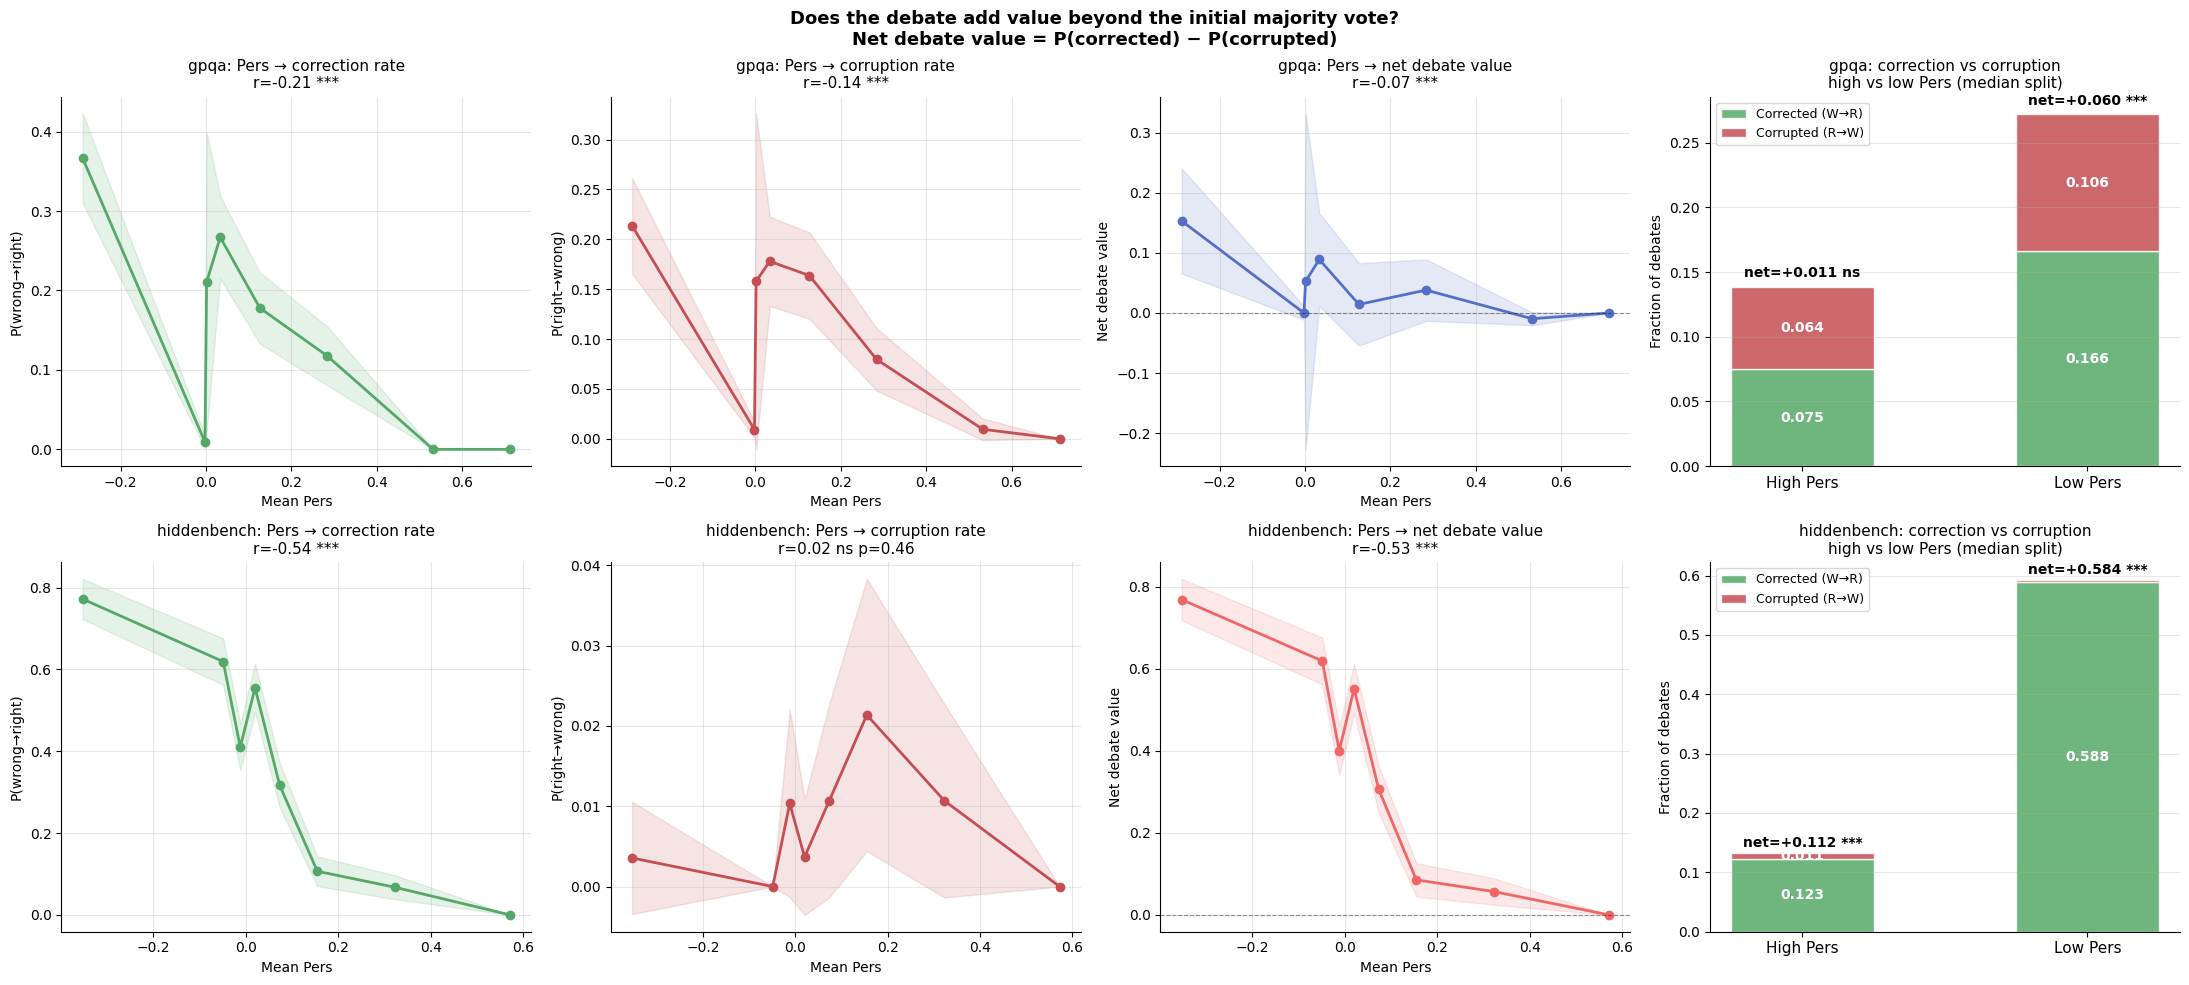

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for row, ds in enumerate(datasets):
    sub   = dv_df[dv_df['dataset']==ds].copy()
    color = DS_COLORS[ds]
    med   = sub['pers_mean'].median()

    def binned_dv(ax, ycol, color, ylabel, title, hline=None):
        bins = np.percentile(sub['pers_mean'], np.linspace(0,100,9))
        bins = np.unique(bins)
        if len(bins) < 3: return
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(sub['pers_mean'], bins=bins, labels=lbls)
        grp  = sub.groupby(cut, observed=False)[ycol]
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=color, alpha=0.15)
        r, p = sp_stats.spearmanr(sub['pers_mean'], sub[ycol])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns p={p:.2f}'
        if hline is not None:
            ax.axhline(hline, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
        ax.set_xlabel('Mean Pers', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'{title}\nr={r:.2f} {sig}', fontsize=11)
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    binned_dv(axes[row,0], 'debate_corrected', '#55A868',
              'P(wrong→right)', f'{ds}: Pers → correction rate')
    binned_dv(axes[row,1], 'debate_corrupted', '#C44E52',
              'P(right→wrong)', f'{ds}: Pers → corruption rate')
    binned_dv(axes[row,2], 'debate_value', color,
              'Net debate value', f'{ds}: Pers → net debate value', hline=0)

    ax = axes[row, 3]
    groups = ['High Pers', 'Low Pers']
    subs   = [sub[sub['pers_mean']>med], sub[sub['pers_mean']<=med]]
    bottoms = np.zeros(2)
    for cat, label, c in [
        ('debate_corrected', 'Corrected (W→R)', '#55A868'),
        ('debate_corrupted', 'Corrupted (R→W)', '#C44E52'),
    ]:
        vals = np.array([s[cat].mean() for s in subs])
        ax.bar([0,1], vals, 0.5, bottom=bottoms, color=c, alpha=0.85,
               edgecolor='white', label=label)
        for i, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 0.01:
                ax.text(i, bot+v/2, f'{v:.3f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottoms += vals
    for i, s in enumerate(subs):
        net = s['debate_value'].mean()
        t, p = sp_stats.ttest_1samp(s['debate_value'], 0)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        ax.text(i, bottoms[i]+0.005, f'net={net:+.3f} {sig}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel('Fraction of debates', fontsize=10)
    ax.set_title(f'{ds}: correction vs corruption\nhigh vs low Pers (median split)', fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle(
    'Does the debate add value beyond the initial majority vote?\n'
    'Net debate value = P(corrected) − P(corrupted)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
# Key Findings — Persuasiveness Analysis

## Score properties
- **Pers and Pers+ are redundant** (Spearman r≈0.99 both datasets). Post-flip confidence adds no signal. Use Pers only.
- **W has no effect on Pers** (r≈0.00, p>0.69 both datasets). Memory window size does not make agents more or less persuasive.
- **Distribution is zero-median** across all conditions — by design, wins and losses cancel at the population level.
- **3-1 starting splits inflate Pers** structurally (median Pers 0.083 gpqa / 0.022 hiddenbench vs ≈−0.04 for balanced configs). Score artifact, not genuine influence.
- `conf_delta` correlates with Pers but is partly mechanistic (confidence is in the formula). Do not interpret as an independent driver.

## What Pers actually measures
Pers is a **debate dominance score** — how much one agent's position steamrolled the others. It is not a measure of argumentative quality.

## Pers and system outcome
- **High Pers → lower accuracy** (r=−0.09 gpqa, r=−0.45 hiddenbench). Within-question partial effect: r=−0.03 ns gpqa, r=−0.34 *** hiddenbench. Effect is concentrated in medium-length debates (T 4–6: r=−0.08 / −0.58), not driven purely by question difficulty.
- **High Pers → faster convergence** (fewer rounds), but speed ≠ quality.
- **Correct-majority + High Pers = best outcome** (0.84 gpqa / 0.93 hiddenbench accuracy).
- **Wrong-majority + High Pers = worst outcome** (0.11 gpqa / 0.11 hiddenbench accuracy). The dominant wrong agent efficiently converts everyone.

## The core finding: deliberative value
The deliberative value of the debate comes almost entirely from **low-Pers** debates:

| | Corrected (W→R) | Corrupted (R→W) | Net value |
|---|---|---|---|
| gpqa  Low Pers  | 16.6% | 10.6% | +0.060 |
| gpqa  High Pers | 7.5%  | 5.5%  | +0.011 |
| hiddenbench Low Pers  | 58.8% | 0.4% | +0.584 |
| hiddenbench High Pers | 12.3% | 1.1% | +0.112 |

**High Pers debates rubber-stamp the initial majority. Low Pers debates are where genuine error correction happens** — the minority correct agent wins ~17–59% of the time.

## Flip direction
- gpqa: toward correct 35.6%, away from correct 33.2% — near-random, slight correct bias.
- hiddenbench: toward correct 41.8%, away from correct 21.1% — clear correct bias despite high overall Pers→accuracy penalty.

## What drives Pers
- **Agents about to flip write shorter, more hedging messages** (significant both datasets) — linguistic uncertainty predicts susceptibility to persuasion.
- **Assertive language and math content are slightly negatively correlated with Pers** — being more technical does not make agents more persuasive.
- **Starting in the majority** gives marginally higher Pers (median 0.000 vs −0.028 to −0.053, significant ***) — small structural artifact.

## Design implications
1. If the goal is accuracy: prefer debate configurations that produce low-Pers dynamics (diverse starting positions, 2-1-1 or 1-1-1-1 splits over 3-1).
2. High Pers is a **warning signal**: a debate where one agent dominates early is likely to lock in whatever that agent believes, correct or not.
3. Hedging language before a flip could be used as an **early-stopping or intervention signal** in future systems.